**[Implement analytics solutions using Microsoft Fabric](https://learn.microsoft.com/en-us/training/courses/dp-600t00/)**

# **[Design and manage semantic models in Microsoft Fabric](https://learn.microsoft.com/training/paths/design-manage-semantic-models-fabric/)**

## **Create DAX calculations in semantic models**

### **Introduction**

#### Why Do We Need DAX?
After creating a semantic model, you usually have:

✅ Tables \
✅ Columns \
✅ Relationships

But the model may still be missing:
* Business calculations
* Time intelligence
* Derived fields
* Additional tables
* Analytical logic

This is where **DAX (Data Analysis Expressions)** comes in.

DAX is the calculation language used in:
* Power BI
* Fabric Semantic Models
* Analysis Services

#### Three Types of DAX Calculations
DAX can create:
##### 1. Calculated Tables
Creates an entirely new table.

**Purpose**

Used for:

✅ Date tables \
✅ Role-playing dimensions \
✅ What-if analysis \
✅ Supporting tables

**Example**
```dax
DateTable =
CALENDAR(
    DATE(2024,1,1),
    DATE(2025,12,31)
)
```
Creates a new Date table.
##### 2. Calculated Columns
Adds a new column to an existing table.

**Purpose**

Used for:

✅ Row-level calculations \
✅ Categories \
✅ Labels \
✅ Derived attributes

**Example**
```dax
Full Name =
Customers[FirstName] &
" " &
Customers[LastName]
```
Creates a Full Name column.

**Characteristics**

✅ Calculated once during data refresh \
✅ Stored in the model \
✅ Increases model size
##### 3. Measures (Most Important)
Measures perform aggregations and calculations dynamically.

**Purpose**

Used for:

✅ Totals \
✅ Averages \
✅ Ratios \
✅ KPIs \
✅ Time intelligence

**Example**
```dax
Total Sales =
SUM(Sales[SalesAmount])
```
**Characteristics**

✅ Calculated at query time \
✅ Not physically stored \
✅ Most common DAX object \
✅ Preferred for analytics
##### Why Measures Matter
A column can only return one value per row.

A measure can return different results depending on the report context.

Example:
```dax
Total Sales =
SUM(Sales[SalesAmount])
```
May return:
```
$100,000 by Region
$25,000 by Product
$5,000 by Customer
```
Same measure, different context.
#### Common Business Requirements Solved by DAX
##### Year-To-Date Sales
```dax
Sales YTD =
TOTALYTD(
    [Total Sales],
    Date[Date]
)
```
##### Profit
```dax
Profit =
SUM(Sales[Revenue]) -
SUM(Sales[Cost])
```
##### Profit Margin
```dax
Profit Margin =
DIVIDE(
    [Profit],
    [Total Sales]
)
```
##### Customer Count
```dax
Customer Count =
DISTINCTCOUNT(
    Sales[CustomerID]
)
```
#### When to Use Each DAX Object
| DAX Object        | Use For                    |
| ----------------- | -------------------------- |
| Calculated Table  | Create new tables          |
| Calculated Column | Row-level calculations     |
| Measure           | Aggregations and analytics |

#### Memory Trick
##### Calculated Table
Creates:
> New Table

##### Calculated Column
Creates:
> New Column

##### Measure
Creates:
> New Calculation

#### Storage Impact
| Object            | Stored in Model? |
| ----------------- | ---------------- |
| Calculated Table  | ✅ Yes            |
| Calculated Column | ✅ Yes            |
| Measure           | ❌ No             |

##### Exam Tip
Measures usually have the best efficiency because they do not increase model storage significantly.
#### Typical Semantic Model Design
> Tables → Relationships → Calculated Columns → Measures → Reports → Copilot

#### DAX and AI
Well-designed measures help:

✅ Power BI Copilot \
✅ Fabric AI experiences \
✅ Natural language queries \
✅ Semantic models

Example question:
> Show YTD sales by region.

Copilot can use existing DAX measures to answer accurately.
#### Exam Quick Facts
✅ DAX = Data Analysis Expressions \
✅ Used in:
* Power BI
* Fabric Semantic Models

✅ DAX creates:
* Calculated Tables
* Calculated Columns
* Measures

✅ Calculated Tables create new tables \
✅ Calculated Columns create new columns \
✅ Measures perform aggregations \
✅ Measures are calculated dynamically at query time \
✅ Measures are generally preferred over calculated columns for analytical calculations \
✅ Time intelligence calculations such as YTD commonly use DAX measures
#### Memory Trick
* Table → New Table
* Column → New Column
* Measure → New Insight ⭐

For exams, if asked:
> *Which DAX object is used for summaries, KPIs, totals, and YTD calculations?*

✅ Measure.

### **Create calculated tables**

#### What is a Calculated Table?
A **Calculated Table** is a table created using a DAX formula that returns a table object.

Unlike imported tables:

✅ Created inside the semantic model \
✅ Recalculated during refresh \
✅ Can duplicate or transform existing data \
✅ Useful for modeling scenarios
#### Why Use Calculated Tables?
Common use cases:
##### 1. Role-Playing Dimensions
Example:
> Order Date \
> Ship Date \
> Due Date

all use the same Date table.
##### 2. Date Tables
Required for:

✅ Time Intelligence \
✅ YTD calculations \
✅ MTD calculations \
✅ Fiscal calendar analysis
##### 3. What-If Analysis
Create custom parameter tables for simulation.
##### 4. Supporting Tables
Create lookup or helper tables directly in the model.
#### Duplicate a Table
##### Problem: Multiple Relationships
Example:

**Sales Table**

Contains:
```
OrderDateKey
ShipDateKey
DueDateKey
```
linked to:
```
Date Table
```
**Relationship Limitation**

Only one relationship can be:

✅ Active

Other relationships become:

❌ Inactive
##### Solution: Create a Duplicate Table
Example:
```
Ship Date = 'Date'
```
**What Happens?**

A new table:
```
Ship Date
```
is created with:

✅ Same rows \
✅ Same columns \
✅ Same data

as:
```
Date
```
**Benefit**

You can now create a separate active relationship:
> Sales[`ShipDateKey`] → Ship Date

while retaining:
> Sales[`OrderDateKey`] → Date

#### Role-Playing Dimensions
A duplicated Date table is called a:
##### Role-Playing Dimension
Because one date table serves different roles:
> Order Date \
> Ship Date \
> Due Date

**Exam Tip**

Most common calculated table scenario:

✅ Duplicate Date table \
✅ Create role-playing dimensions
#### Configure Duplicate Tables
The duplicate table does NOT automatically inherit all customizations.

You may need to:
##### Rename Columns
Example:
> Fiscal Year

becomes
> Ship Fiscal Year

##### Configure Sorting
Example:
> Ship Full Date

sorted by:
> Ship Date

##### Hide Supporting Columns
Example:
```
MonthKey
```
used for sorting but hidden from users.
#### Limitation of Duplicate Tables
Calculated tables:

✅ Useful

But:

❌ Increase model size \
❌ Increase refresh duration \
❌ Consume memory
##### Exam Tip
Role-playing dimensions work well but may not be the most performant solution.
#### Create a Date Table
##### Why Date Tables Matter
Required for:

✅ Time Intelligence

Examples:
```dax
TOTALYTD()
DATESYTD()
SAMEPERIODLASTYEAR()
```
#### Using `CALENDARAUTO`
Most common approach.

Example:
```dax
Due Date = CALENDARAUTO(6)
```
##### How It Works
`CALENDARAUTO()` scans:
> All Date Columns \
> All DateTime Columns

in the model.

It automatically finds:
> Earliest Date \
> Latest Date

and generates a complete date range.
##### Fiscal Year Argument
Example:
```dax
CALENDARAUTO(6)
```
means:
> June = Fiscal Year End

Fiscal year:
> July → June

##### Result
Creates:
> One Column

containing every date.

Example:
```
2021-07-01
2021-07-02
...
2022-06-30
```
#### `CALENDAR` Function
Alternative approach.

Example:
```dax
DateTable =
CALENDAR(
    DATE(2020,1,1),
    DATE(2030,12,31)
)
```
##### Difference
| Function     | Behavior                        |
| ------------ | ------------------------------- |
| CALENDARAUTO | Automatically finds date range  |
| CALENDAR     | Explicitly specifies date range |

#### Mark as Date Table
After creating a Date Table:
##### Important Step
> Mark as Date Table

in Power BI.
##### Why Mark It?
Enables:

✅ Time Intelligence Functions \
✅ Correct Date Behavior \
✅ Calendar-Based Calculations
#### Date Table Validation Rules
Power BI checks that:
##### 1. Values Are Unique
* No duplicate dates
##### 2. No Null Values
* Every row must contain a date
##### 3. Dates Are Contiguous
* No gaps

Example:
```
Jan 1
Jan 2
Jan 3
```
not:
```
Jan 1
Jan 3
Jan 5
```
##### 4. Consistent Time Value
For DateTime:
* Same timestamp throughout
#### Date Tables and Time Intelligence
Many DAX functions require a proper Date Table.

Examples:
```dax
TOTALYTD()

DATESMTD()

SAMEPERIODLASTYEAR()
```
Without a valid Date Table:

❌ These calculations may not work correctly.
#### Auto Date/Time vs Date Table
Power BI provides:
##### Auto Date/Time
✅ Easy \
❌ Limited customization \
❌ Hidden tables
##### Custom Date Table
✅ Recommended \
✅ Fully customizable \
✅ Supports fiscal calendars \
✅ Better enterprise solution
#### Calculated Table Summary
| Use Case               | Example                |
| ---------------------- | ---------------------- |
| Duplicate Table        | Ship Date = 'Date'     |
| Role-Playing Dimension | Order Date / Ship Date |
| Date Table             | CALENDARAUTO()         |
| What-If Analysis       | Parameter tables       |
| Helper Tables          | Lookup tables          |

#### Exam Quick Facts
✅ Calculated Tables return tables using DAX \
✅ Created inside the semantic model \
✅ Common role-playing dimension example:
```dax
Ship Date = 'Date'
```
✅ Duplicate tables support multiple active relationships \
✅ Calculated tables increase:
* Model size
* Refresh duration

✅ Date tables are required for time intelligence \
✅ Most common function:
```dax
CALENDARAUTO()
```
✅ Alternative:
```dax
CALENDAR()
```
✅ Date tables should be marked as Date Tables \
✅ Valid date tables require:
* Unique values
* No nulls
* Contiguous dates
* Consistent timestamps
#### Memory Trick
> Calculated Table = New Table

Most common examples:
```dax
Ship Date = 'Date'
```
and
```dax
DateTable = CALENDARAUTO()
```
For exams, if asked:
> *Which DAX object is commonly used to create a Date Table or Role-Playing Dimension?*

✅ Calculated Table. ⭐

### **Create calculated columns**

#### What is a Calculated Column?
A **Calculated Column** is a column added to a table using a DAX formula.

The formula returns **one value for each row** in the table.

Example:
```dax
Full Name =
Customer[First Name]
& " "
& Customer[Last Name]
```
Result:
| First Name | Last Name | Full Name  |
| ---------- | --------- | ---------- |
| John       | Smith     | John Smith |

#### When Should You Use Calculated Columns?
##### Preferred Order
✅ Source System \
✅ Power Query Custom Column \
✅ DAX Calculated Column (only when needed)

Microsoft generally recommends:

**Power Query columns over DAX calculated columns**

because they are:
* More efficient
* More compressed
* Better for model size
#### When to Use Calculated Columns
Use a calculated column when:
##### 1. Working with Calculated Tables
Example:
* Fiscal Year
* Fiscal Quarter
* Month Key

added to a Date table.
##### 2. DAX-Specific Functions Are Required
Examples:
```dax
RELATED()
RELATEDTABLE()
LOOKUPVALUE()
```
These functions aren't available in Power Query.
##### 3. Depends on Model Relationships
If the calculation needs data from related tables.
#### Important Characteristics
Calculated columns:

✅ Evaluated during refresh \
✅ Stored physically in the model \
✅ Increase model size \
✅ Increase refresh time \
❌ Not calculated dynamically
#### Calculated Columns vs Measures
| Feature                       | Calculated Column | Measure                    |
| ----------------------------- | ----------------- | -------------------------- |
| Stored in model               | ✅ Yes             | ❌ No                       |
| Uses row context              | ✅ Yes             | ❌ Typically filter context |
| Increases model size          | ✅ Yes             | ❌ No                       |
| Calculated at refresh         | ✅ Yes             | ❌ Query time               |
| Used for slicers and grouping | ✅ Yes             | ❌ No                       |
##### Exam Tip
If the result is needed for:
> Rows \
> Filters \
> Grouping \
> Slicers

**→ Calculated Column**

If the result is:
> Totals \
> KPIs \
> Aggregations

**→ Measure**
#### Example 1: Fiscal Year
Creates financial year labels.

Fiscal year:
> July → June

##### DAX
```dax
Due Fiscal Year =
"FY"
    & YEAR('Due Date'[Due Date])
        +
        IF(
            MONTH('Due Date'[Due Date]) > 6,
            1
        )
```
##### Example Results
| Date     | Fiscal Year |
| -------- | ----------- |
| Jan 2024 | FY2024      |
| Aug 2024 | FY2025      |

##### Exam Concept
Uses:
```dax
YEAR()
MONTH()
IF()
```
functions.
#### Example 2: Fiscal Quarter
Creates fiscal quarter labels.
##### DAX
```dax
Due Fiscal Quarter =
'Due Date'[Due Fiscal Year]
    & " Q"
    & ...
```
##### Example Results
| Date         | Fiscal Quarter |
| ------------ | -------------- |
| July 2024    | FY2025 Q1      |
| October 2024 | FY2025 Q2      |

##### Purpose
Creates ready-to-use reporting dimensions.
#### Example 3: Month Key
Creates a sorting column.
##### DAX
```dax
MonthKey =
(YEAR('Due Date'[Due Date]) * 100)
    +
MONTH('Due Date'[Due Date])
```
##### Example Results
| Date     | MonthKey |
| -------- | -------- |
| Jan 2024 | 202401   |
| Feb 2024 | 202402   |

##### Purpose
Used for:

✅ Sorting months chronologically

Without it:
> April \
> August \
> December \
> February

might sort alphabetically.
#### Example 4: Full Date Label
Uses `FORMAT`.
##### DAX
```dax
Due Full Date =
FORMAT(
    'Due Date'[Due Date],
    "yyyy mmm, dd"
)
```
##### Example Result
`2024 Jan, 15`
##### `FORMAT` Function
Converts values into text.

Often used for:

✅ Date labels \
✅ Display formatting \
✅ Friendly report names
#### Understanding Row Context
##### Most Important Calculated Column Concept
**What is Row Context?**

Row Context means:
> *DAX evaluates the formula one row at a time.*

Think:
> Current Row

##### Example
```dax
MonthKey =
YEAR('Due Date'[Due Date]) * 100
+
MONTH('Due Date'[Due Date])
```
For each row:
* Read current row date
* Calculate value
* Store result
* Move to next row
##### Exam Definition
✅ Row Context = Current Row
#### Row Context Example
| Date       |
| ---------- |
| 2024-01-15 |
| 2024-02-20 |

Row 1:
> 202401

Row 2:
> 202402

Each row is evaluated individually.
#### Accessing Other Tables
* Row context only applies to the current table.
* To retrieve values from another table:
#### `RELATED()`
Most common exam function.

Used when:

✅ Relationship exists \
✅ Need value from "one" side
##### Example
```dax
RELATED(Product[List Price])
```
##### Memory
```dax
RELATED = Bring one value
```
#### `RELATEDTABLE()`
Returns rows from the many-side.
##### Example
```dax
RELATEDTABLE(Sales)
```
##### Memory
```dax
RELATEDTABLE = Bring a table
```
#### `LOOKUPVALUE()`
Used when:

❌ No relationship exists \
✅ Need to find a matching value
##### Example
```dax
LOOKUPVALUE(...)
```
##### Exam Tip
Prefer:
```dax
RELATED()
```
over:
```dax
LOOKUPVALUE()
```
because it's usually faster.
#### Real Example Using RELATED
##### DAX
```dax
Discount Amount =
(
    Sales[Order Quantity]
        *
        RELATED(Product[List Price])
)
-
Sales[Sales Amount]
```
##### How It Works
For every Sales row:

**Get From Current Sales Row**
* Order Quantity
* Sales Amount

**Get From Product Table**
* List Price

using:
```dax
RELATED()
```
**Calculate**
```
(Expected Price) - (Actual Sales Amount)
```
#### Storage Impact
Remember:

Every calculated column:

✅ Stores values \
✅ Increases memory usage \
✅ Refreshes during dataset refresh

Large models can become significantly larger.
#### Best Practice
Use:

✅ Calculated Columns for categories, labels, sorting columns, relationships

Use:

✅ Measures for totals and aggregations

Avoid creating calculated columns when a measure can solve the problem.
#### Exam Quick Facts

✅ Calculated columns return one value per row \
✅ Evaluated during refresh \
✅ Stored in the model \
✅ Increase model size \
✅ Row Context = Current Row \
✅ Common functions:
* `YEAR()`
* `MONTH()`
* `IF()`
* `FORMAT()`

✅ Relationship functions:
* `RELATED()`
* `RELATEDTABLE()`

✅ No relationship:
* `LOOKUPVALUE()`

✅ `RELATED()` is generally faster than `LOOKUPVALUE()`

✅ Calculated columns are often used for:
* Fiscal Year
* Fiscal Quarter
* Sort Keys
* Display Labels
#### Memory Trick
> Calculated Column = One Value Per Row

and
> Row Context = Current Row ⭐

For exams, if asked:
> *Which DAX concept is automatically available when evaluating a calculated column?*

✅ Row Context.

### **Understand implicit measures**

#### What are Implicit Measures?
An **Implicit Measure** is an automatic aggregation created by Power BI when you drag a numeric column into a visual.

You do **not write DAX** for an implicit measure.

Example:
> Sales Amount Column → Added to Visual → Power BI automatically applies `SUM`

#### Implicit vs Explicit Measures
| Type             | Created By             | DAX Required? |
| ---------------- | ---------------------- | ------------- |
| Implicit Measure | Power BI automatically | ❌ No          |
| Explicit Measure | Model designer         | ✅ Yes         |

##### Examples
**Implicit**
> Sales Amount

Power BI automatically calculates:
```
SUM(Sales Amount)
```
**Explicit**
```dax
Total Sales =
SUM(Sales[Sales Amount])
```
Created manually using DAX.
#### How to Identify Implicit Measures
In the Fields/Data pane:
##### Sigma Symbol (∑)
`∑ Sales Amount`

means:

✅ Numeric column \
✅ Can be automatically summarized
##### No Sigma Symbol
Means:
> Don't Summarize

is configured.

Example:
```
Customer ID
Order Number
```
These shouldn't be aggregated.
#### Summarization Property
As a modeler, you control:
> Summarization

Options include:

✅ Sum \
✅ Average \
✅ Min \
✅ Max \
✅ Don't Summarize
#### Example: Sales Amount
Column:
> Sales Amount

Default behavior:
```
SUM(Sales Amount)
```
When placed into a visual.
##### Example
| Month | Sales |
| ----- | ----- |
| Jan   | 100   |
| Feb   | 200   |

Visual shows:
> Total = 300

because Power BI automatically applies:
```
SUM()
```
#### Example: Unit Price
Unit Price is a:
> Rate

not a total.

Power BI therefore commonly defaults to:
```
AVERAGE()
```
instead of:
```
SUM()
```
##### Why?
Adding prices together is usually meaningless.

Example:
```
10
20
30
```
Average:
> 20 ✅

Sum:
> 60 ❌

#### Aggregations Available for Numeric Columns
Numeric fields support the largest number of aggregation options.
##### `SUM`
Total Sales
##### `AVERAGE`
Average Price
##### `MIN`
Lowest Sale
##### `MAX`
Highest Sale
##### `COUNT`
Number of Rows
##### `DISTINCT COUNT`
Unique Customers
##### `MEDIAN`
Middle value.
##### `STANDARD DEVIATION`
Measures variation.
##### `VARIANCE`
Measures spread of data.
#### Non-Numeric Columns Can Also Be Summarized
Many learners think only numbers can be aggregated.

That's incorrect.
##### Text Columns
Examples:
> Product Name \
> Customer Name

Available aggregations:

✅ First \
✅ Last \
✅ Count \
✅ Distinct Count 

**Example**

Question:
> How many unique products exist?

Use:
```
Distinct Count(Product Name)
```
##### Date Columns
Examples:
> Order Date \
> Ship Date

Available aggregations:

✅ Earliest \
✅ Latest \
✅ Count \
✅ Distinct Count

**Example**

Question:
> What is the earliest order date?

Use:
```
Earliest(Order Date)
```
##### Boolean Columns
Examples:
> Complete \
> Approved \
> Active

Can also be counted.

Example:
> How many orders were completed?

Use:
```
Count()
```
#### Why Implicit Measures Are Useful
##### Benefit 1: Easy to Use
No DAX required.

Simply:
> Drag Column → Get Result

##### Benefit 2: Fast Report Creation
Report authors don't need:
```
SUM()
AVG()
COUNT()
```
measures created beforehand.
##### Benefit 3: Less Work for Modelers
No need to create:
> Total Sales \
> Total Profit \
> Total Quantity

for every basic metric.
#### Limitations of Implicit Measures
##### Report Authors Can Change Aggregations
Example:
> Unit Price

should use:
> Average

but a user can choose:
> Sum

Result:
> Potentially misleading analysis

#### Only Simple Calculations Supported
Implicit measures can only perform:

✅ One aggregation function

Examples:
```
SUM
AVG
MIN
MAX
```
They cannot perform:

❌ Ratios \
❌ YTD calculations \
❌ Running totals \
❌ Profit margins \
❌ Complex time intelligence
#### Example of a Calculation Requiring an Explicit Measure
Question:
> What percentage of annual sales does each month represent?

Requires:
```dax
Monthly % of Year =
DIVIDE(
    [Monthly Sales],
    [Yearly Sales]
)
```
Implicit measures cannot do this.
#### When to Use Implicit Measures
✅ Quick reports \
✅ Basic totals \
✅ Simple analysis \
✅ Ad hoc reporting
#### When to Use Explicit Measures
✅ Business KPIs \
✅ Financial metrics \
✅ Ratios \
✅ YTD calculations \
✅ Time intelligence \
✅ Reusable calculations
#### Implicit vs Explicit Measures
| Feature                 | Implicit Measure | Explicit Measure |
| ----------------------- | ---------------- | ---------------- |
| DAX Required            | ❌ No             | ✅ Yes            |
| Easy to Use             | ✅ Yes            | ⚠ Requires DAX   |
| Simple Aggregations     | ✅ Yes            | ✅ Yes            |
| Time Intelligence       | ❌ No             | ✅ Yes            |
| Ratios                  | ❌ No             | ✅ Yes            |
| KPIs                    | ❌ No             | ✅ Yes            |
| Reusable Business Logic | ❌ No             | ✅ Yes            |

#### Exam Quick Facts
✅ Implicit measures are automatically created by Power BI \
✅ Numeric columns with `∑` can be summarized \
✅ Common implicit aggregations:
* Sum
* Average
* Min
* Max
* Count
* Distinct Count
* Median
* Standard Deviation
* Variance

✅ Non-numeric fields can also be aggregated \
✅ Summarization behavior is controlled by the Summarization property \
✅ Implicit measures require no DAX \
✅ Implicit measures are limited to simple aggregations \
✅ Complex calculations require explicit measures
#### Memory Trick
**Implicit = Automatic**
> Drag Column → Power BI Aggregates

**Explicit = DAX Written by You**

For exams:
> *If a calculation requires ratios, YTD totals, running totals, or KPIs...*

✅ Use an Explicit Measure, not an implicit one. ⭐

### **Create explicit measures**

#### What is an Explicit Measure?
An **Explicit Measure** is a DAX calculation that you create manually.

Unlike implicit measures:

✅ Written using DAX \
✅ Calculated at query time \
✅ Not stored in the model \
✅ More powerful and flexible
#### Implicit vs Explicit Measures
##### Implicit Measure
Created automatically.

Example:
> Sales Amount

Power BI automatically applies:
```
SUM(Sales Amount)
```
##### Explicit Measure
Created manually using DAX.

Example:
```dax
Revenue =
SUM(Sales[Sales Amount])
```
#### Key Characteristics of Measures
Measures:

✅ Return a single value \
✅ Do not store data \
✅ Use filter context \
✅ Calculated dynamically \
✅ Consume very little model storage

##### Exam Tip
Measures are evaluated:
> At Query Time

NOT during refresh.
#### Creating a Simple Measure
##### Revenue Measure
```dax
Revenue =
SUM(Sales[Sales Amount])
```
##### Purpose
Aggregates:
> Sales Amount

into:
> Total Revenue

**Result**

Depending on report filters:
* Revenue by Year
* Revenue by Product
* Revenue by Customer

The same measure returns different values.
#### Measure Best Practice
Instead of exposing raw columns:
> Sales Amount \
> Profit Amount

Create measures:
> Revenue \
> Profit

and hide unnecessary columns.

Benefits:

✅ Easier report creation \
✅ Consistent business logic \
✅ Better governance
#### Formatting Measures
After creation:

Configure:

✅ Data Type \
✅ Currency Format \
✅ Percentage Format \
✅ Decimal Places \
✅ Home Table
##### Home Table
The table where the measure appears in the Fields pane.

Example:
```
Sales Table
```
contains:
```
Revenue
Profit
Margin
```
#### `COUNT` Measures
##### `COUNT()`
Counts non-blank values.

Example:
```dax
Order Line Count =
COUNT(
    Sales[SalesOrderLineKey]
)
```
**Result**

Counts every sales line.
##### `DISTINCTCOUNT()`
Counts unique values.

Example:
```dax
Order Count =
DISTINCTCOUNT(
    Sales[Sales Order]
)
```
Why Use It?

One order may have:
```
Line 1
Line 2
Line 3
```
`COUNT`:
```
3
```
`DISTINCTCOUNT`:
```
1
```
Correct order count.
##### COUNT vs DISTINCTCOUNT
| Function      | Counts        |
| ------------- | ------------- |
| COUNT         | All values    |
| DISTINCTCOUNT | Unique values |

##### Exam Question
Customer purchased:
```
100
100
101
101
102
```
`COUNT`:
```
5
```
`DISTINCTCOUNT`:
```
3
```
##### `COUNTROWS()`
Counts table rows.

Example:
```dax
Order Line Count =
COUNTROWS(Sales)
```
**Difference**
```dax
COUNT(Column)
```
Counts values in a column.
```dax
COUNTROWS(Table)
```
Counts rows in a table.
#### Simple Measures
Simple measures summarize:

✅ One column \
✅ One table

Examples:
```dax
SUM()
COUNT()
DISTINCTCOUNT()
COUNTROWS()
AVG()
```
##### Compound Measures
Most important exam concept.
##### What is a Compound Measure?
A measure built using other measures.

Example
```dax
Revenue =
SUM(Sales[Sales Amount])
```
```dax
Cost =
SUM(Sales[Cost Amount])
```
```dax
Profit =
[Revenue] - [Cost]
```
##### Why Is This Better?
Instead of creating:
> Profit Amount Column

for every row,

you create:
> Profit Measure

which:

✅ Uses less memory \
✅ Refreshes faster \
✅ Keeps model smaller
#### Calculated Column vs Measure
Bad approach:
```dax
Profit Amount Column =
Revenue - Cost
```
Stored for every row.

Better approach:
```dax
Profit =
[Revenue] - [Cost]
```
Calculated only when needed.
##### Exam Tip
Whenever possible:

✅ Use measures instead of calculated columns.
#### Measure Dependency
Measures can reference:

✅ Columns \
✅ Other Measures
##### Example
```dax
Profit =
[Revenue]
-
[Cost]
```
##### Dependency Chain
> Revenue → Profit → Profit Margin

Be cautious:
> Changing one measure can affect many others.

#### Quick Measures
##### What Are Quick Measures?
* Power BI generates DAX automatically.
* No manual coding required.

##### Example
Profit Margin

Steps:
> New Quick Measure → Division → Profit / Revenue

Generated DAX:
```dax
Profit Margin =
DIVIDE(
    [Profit],
    [Revenue]
)
```
#### `DIVIDE` Function
Preferred over:
> Profit / Revenue

because:

✅ Handles divide-by-zero safely

Example:
```dax
DIVIDE(
    [Profit],
    [Revenue]
)
```
#### Common Measure Functions
##### `SUM`
```dax
SUM(Sales[Sales Amount])
```
##### `COUNT`
```dax
COUNT(Sales[OrderID])
```
##### `COUNTROWS`
```dax
COUNTROWS(Sales)
```
##### `DISTINCTCOUNT`
```dax
DISTINCTCOUNT(Customer[CustomerID])
```
##### `DIVIDE`
```dax
DIVIDE([Profit],[Revenue])
```
#### Calculated Columns vs Measures
| Feature             | Calculated Column  | Measure            |
| ------------------- | ------------------ | ------------------ |
| Stored in model     | ✅ Yes              | ❌ No               |
| Uses row context    | ✅ Yes              | ❌ Typically        |
| Uses filter context | ❌ Not primarily    | ✅ Yes              |
| Refresh time impact | ✅ Higher           | ✅ Lower            |
| Model size impact   | ✅ Increases        | ❌ Minimal          |
| Good for            | Categories, labels | Aggregations, KPIs |

#### Exam Rule
##### Use Calculated Column When
Need:
* Fiscal Year
* Category
* Sort Column
* Grouping Field
##### Use Measure When
Need:
* Revenue
* Profit
* Margin
* YTD
* KPIs
* Ratios
#### Filter Context
Measures evaluate using:
##### Filter Context
Example:
```dax
Revenue =
SUM(Sales[Sales Amount])
```
Visual:
```
Year = 2024
```
Result:
```
Revenue for 2024
```
Change filter:
```
Year = 2025
```
Measure recalculates automatically.
#### Exam Memory
* Calculated Column → Row Context
* Measure → Filter Context
#### Best Practices
✅ Create explicit measures for business metrics \
✅ Format measures immediately \
✅ Use compound measures \
✅ Prefer measures over calculated columns \
✅ Use `DIVIDE` instead of `/` \
✅ Hide raw columns if measures are available
#### Exam Quick Facts
✅ Explicit measures use DAX \
✅ Return a scalar value \
✅ Evaluated at query time \
✅ Not stored in the model \
✅ Use filter context \
✅ Simple measures aggregate one column \
✅ Compound measures reference other measures \
✅ Common functions:
* `SUM`
* `COUNT`
* `DISTINCTCOUNT`
* `COUNTROWS`
* `DIVIDE`

✅ Quick Measures automatically generate DAX \
✅ Measures are generally more efficient than calculated columns
#### Memory Trick
**Measure = Dynamic Calculation**
> Calculated Column → Stored \
> Measure → Calculated

And remember:
* Row Context = Calculated Columns
* Filter Context = Measures ⭐

This is one of the most frequently tested Power BI/DAX exam concepts.

### **Use iterator functions**

#### What are Iterator Functions?
**Iterator functions** evaluate an expression row by row over a table and then aggregate the results.

They provide more flexibility than simple aggregation functions.

Think:
> For each row → Calculate expression → Aggregate results

#### X Functions = Iterator Functions
Most aggregation functions have an iterator equivalent ending in X.

| Standard Function | Iterator Function |
| ----------------- | ----------------- |
| SUM               | SUMX              |
| COUNT             | COUNTX            |
| MIN               | MINX              |
| MAX               | MAXX              |
| AVERAGE           | AVERAGEX          |
| RANK              | RANKX             |

#### Syntax Pattern
All iterator functions require:
```dax
FunctionX(
    Table,
    Expression
)
```
##### Components
Table
> Rows to iterate over

##### Expression
> Calculation performed for each row

#### `SUM` vs `SUMX`
##### `SUM`
```dax
Revenue =
SUM(Sales[Sales Amount])
```
Simply sums one column.
##### `SUMX`
```dax
Revenue =
SUMX(
    Sales,
    Sales[Sales Amount]
)
```
Returns exactly the same result.
##### Exam Fact
Power BI internally treats:
```dax
SUM()
```
as a simplified version of:
```dax
SUMX()
```
#### Why Use Iterator Functions?
Use iterator functions when calculations involve:

✅ Multiple columns \
✅ Related tables \
✅ Complex row-level logic \
✅ Custom aggregation grain
#### Example: Revenue Calculation
Suppose revenue must consider:
> Quantity \
> Price \
> Discount

##### DAX
```dax
Revenue =
SUMX(
    Sales,
    Sales[Order Quantity]
        * Sales[Unit Price]
        * (1 - Sales[Unit Price Discount Pct])
)
```
##### What Happens?
For each row:
> Quantity × Price × Discount

Then:
> All rows summed together

#### Using `RELATED` with Iterators
Iterator functions can access columns from related tables.
##### Example
```dax
Discount =
SUMX(
    Sales,
    Sales[Order Quantity]
        *
        (
            RELATED(Product[List Price])
            -
            Sales[Unit Price]
        )
)
```
##### Purpose
For every sales row:
* Get Product List Price
* Compare To Actual Price
* Calculate Discount

Then total all discounts.
##### Performance Tip
Prefer:
```dax
RELATED()
```
instead of:
```dax
LOOKUPVALUE()
```
because RELATED is generally faster.
##### Expensive Functions
Be cautious with:
```dax
SEARCH()
LOOKUPVALUE()
```
especially on large tables.
#### Iterator Functions and Row Context
Iterator functions automatically create:
##### Row Context
Meaning:
> Current Row

is available during evaluation.

Example:
```dax
SUMX(Sales, Sales[Quantity] * Sales[Price])
```
For each row:
* Current Quantity
* Current Price

are evaluated.
#### Iterator Functions and Filter Context
First:
> Filter Context Applied

Then:
> Iterator Processes Remaining Rows

Example:
> Visual filtered to FY2024

Iterator only processes FY2024 sales rows.
#### `AVERAGEX`
Average Per Order Line
##### Example
```dax
Revenue Avg Order Line =
AVERAGEX(
    Sales,
    Sales[Order Quantity]
        * Sales[Unit Price]
        * (1 - Sales[Unit Price Discount Pct])
)
```
##### Result
Calculates:
* Average Revenue
* Per Line Item
#### Higher Grain Calculations
Iterator functions can summarize at different levels.
#### Average Revenue Per Order
One order may contain:
```
Line 1
Line 2
Line 3
```
Instead of averaging line items:
> Average complete orders.

##### Example
```dax
Revenue Avg Order =
AVERAGEX(
    VALUES('Sales Order'[Sales Order]),
    [Revenue]
)
```
#### `VALUES` Function
##### Purpose
Returns unique values.

Example:
```dax
VALUES(
    'Sales Order'[Sales Order]
)
```
returns:
```
Order 100
Order 101
Order 102
```
without duplicates.
##### Exam Fact
VALUES is commonly used with:
```dax
AVERAGEX
SUMX
RANKX
```
to change aggregation grain.
#### Ranking with `RANKX`
One of the most important iterator functions.
##### Example
```dax
Product Quantity Rank =
RANKX(
    ALL('Product'[Product]),
    [Quantity]
)
```
##### Purpose
Ranks products by quantity sold.
#### `ALL` Function
```dax
ALL(Product[Product])
```
removes filters.

This allows ranking against:
> All Products

instead of only filtered products.
#### Default Ranking Behavior
`RANKX` defaults to:

✅ Descending Order \
✅ Ties Skip Numbers
##### Example
```
1
2
2
4
```
`Rank 3` is skipped.
#### Dense Ranking
Use:
```dax
DENSE
```
argument.
##### Example
```dax
Product Quantity Rank =
RANKX(
    ALL('Product'[Product]),
    [Quantity],
    ,
    ,
    DENSE
)
```
##### Result
Ranks become:
```
1
2
2
3
```
No skipped numbers.
#### Prevent Ranking Totals
Totals often produce:
> Rank = 1

which isn't meaningful.
#### `HASONEVALUE`
Use:
```dax
HASONEVALUE()
```
to suppress totals.
##### Example
```dax
Product Quantity Rank =
IF(
    HASONEVALUE(
        'Product'[Product]
    ),
    RANKX(
        ALL('Product'[Product]),
        [Quantity],
        ,
        ,
        DENSE
    )
)
```
##### What Happens?
**Product Row**
> Single Product

Result:
> Show Rank

**Total Row**
> Many Products

Result:
> BLANK

#### Most Common Iterator Functions
| Function   | Purpose                  |
| ---------- | ------------------------ |
| `SUMX`     | Custom summation         |
| `AVERAGEX` | Custom averaging         |
| `COUNTX`   | Count expression results |
| `MINX`     | Minimum expression value |
| `MAXX`     | Maximum expression value |
| `RANKX`    | Ranking                  |

#### When to Use Iterators
Use iterator functions when:

✅ Multiple columns are involved \
✅ Need row-by-row calculations \
✅ Need custom aggregation logic \
✅ Need rankings \
✅ Need different aggregation grain
#### Iterator vs Regular Aggregation
##### Regular Aggregation
```dax
SUM(Sales[Amount])
```
One column only.
##### Iterator
```dax
SUMX(
    Sales,
    Sales[Qty]
        * Sales[Price]
)
```
* Multiple columns.
* Much more flexible.
#### Exam Quick Facts
✅ Iterator functions end with X

Examples:
```
SUMX
AVERAGEX
COUNTX
MINX
MAXX
RANKX
```
✅ Require:
> Table + Expression

✅ Create row context automatically \
✅ Evaluate rows one at a time \
✅ Can reference multiple columns \
✅ Can use `RELATED()` \
✅ `VALUES()` returns unique values \
✅ `RANKX()` performs ranking \
✅ `ALL()` removes filters \
✅ `HASONEVALUE()` often hides total-row rankings \
✅ DENSE ranking does not skip numbers
#### Memory Trick
**X = eXamine Every Row**
> SUM   → One Column \
> SUMX  → Row-by-Row Calculation

And remember the four most tested iterator functions:

✅ SUMX → Custom Totals \
✅ AVERAGEX → Custom Averages \
✅ RANKX → Ranking \
✅ VALUES + Iterator → Change Aggregation Grain ⭐

### **Exercise - Create DAX calculations**

#### Get started
To complete this exercise, first open a web browser and enter the following URL to download the zip file:

https://github.com/MicrosoftLearning/PL-300-Microsoft-Power-BI-Data-Analyst/raw/Main/Allfiles/Labs/04-create-dax-calculations\04-dax-calculations.zip

Extract the file to the **C:\Users\Student\Downloads\04-dax-calculations** folder.

Open the **04-Starter-Sales Analysis.pbix** file.
> Note: You may see a sign-in dialog as the file loads. Select Cancel to dismiss the sign-in dialog. Close any other informational windows. Select Apply Later, if prompted to apply changes.

#### Create the Salesperson calculated table
In this task, you’ll create the `Salesperson` calculated table (that will have a direct relationship to the `Sales` table).

A calculated table is created by first entering the table name, followed by the equals symbol (=), followed by a DAX formula that returns a table. The table name can’t already exist in the data model.

You enter a valid DAX formula in the formula bar. The formula bar includes features like auto-complete, Intellisense and color-coding, which allow you to quickly and accurately enter the formula.
1. In Power BI Desktop, in **Report view**, on the **Modeling** ribbon, from inside the **Calculations** group, select **New Table**.

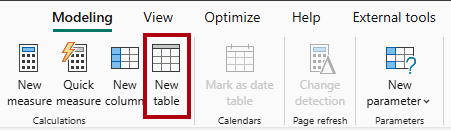

2. In the formula bar (which opens directly beneath the ribbon when you create or edit calculations), type `Salesperson =`, press **Shift+Enter**, type `'Salesperson (Performance)'`, and then press **Enter**.
> Note: For your convenience, all DAX definitions in this lab can be copied from the snippets file, located in the *04-dax-calculations\Snippets.txt* file.

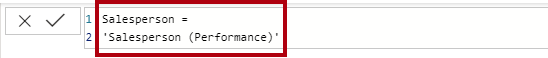

> This table definition creates a copy of the `Salesperson (Performance)` table. It copies the data only, however model properties like visibility, formatting, and others aren’t copied.

3. In the **Data** pane, notice that the icon for the new table has an additional calculator in front of it (denoting a calculated table).

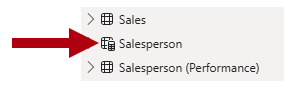

> Note: Calculated tables are defined by using a DAX formula that returns a table. It’s important to understand that calculated tables increase the size of the data model because they materialize and store values. Also, they’re recomputed whenever formula dependencies are refreshed, as will be the case for this data model when new (future) date values are loaded into tables.

> Unlike Power Query-sourced tables, calculated tables can’t be used to load data from external data sources. They can only transform data based on what has already been loaded into the data model.

4. Switch to **Model view**, and notice that the `Salesperson` table is available.
5. Create a relationship from the `Salesperson | EmployeeKey` column to the `Sales | EmployeeKey` column.
> The labs use a shorthand notation to reference a field. It will look like this: `Salesperson | EmployeeKey`. In this example, `Salesperson` is the table name and `EmployeeKey` is the column name.

6. Right-click the inactive relationship (dotted line) between the `Salesperson (Performance)` and `Sales` tables, and then select **Delete**. When prompted to confirm the deletion, select **Yes**.
7. In the `Salesperson` table, multi-select the following columns, and then hide them (set the **Is Hidden** property to **Yes**):
    * `EmployeeID`
    * `EmployeeKey`
    * `UPN`
8. In the model diagram, select the `Salesperson` table.
9. In the **Properties** pane, in the **Description** box, enter: *Salesperson* related to sales
> You may recall that descriptions appear as tooltips in the Data pane whenever the user hovers their cursor over a table or field.

10. For the `Salesperson (Performance)` table, set the description to: *Salesperson related to region(s)*
> The data model now provides two alternatives when analyzing salespeople. The `Salesperson` table allows analyzing sales made by a salesperson, while the `Salesperson (Performance)` table allows analyzing sales made in the sales region(s) assigned to the salesperson.

#### Create the Date table
In this task, you’ll create the `Date` table.
1. Switch to **Table view**. On the **Home** ribbon tab, from inside the **Calculations** group, select **New Table**.

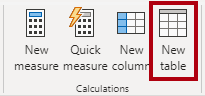

2. In the formula bar, enter the following DAX:

```dax
Date =  
CALENDARAUTO(6)
```
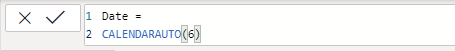

> The `CALENDARAUTO` function returns a single-column table comprising date values. The “auto” behavior scans all data model date columns to determine the earliest and latest date values stored in the data model. It then creates one row for each date within this range, extending the range in either direction to ensure full years of data is stored.

> This function can take a single optional argument that is the last month number of a year. When omitted, the value is 12, meaning that December is the last month of the year. In this case, 6 is entered, meaning that June is the last month of the year.

3. Notice the column of date values which might be formatted using US regional settings (that is, mm/dd/yyyy).

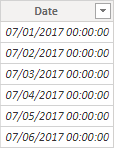

4. At the bottom-left corner, in the status bar, notice the table statistics, confirming that 1826 rows of data have been generated, which represents five full years’ data.



#### Create calculated columns
In this task, you’ll add more columns to enable filtering and grouping by different time periods. You’ll also create a calculated column to control the sort order of other columns.
> Note: For your convenience, all DAX definitions in this lab can be copied from the Snippets.txt file.

1. On the **Table Tools** contextual ribbon, from inside the **Calculations** group, select **New Column**.
> A calculated column is created by first entering the column name, followed by the equals symbol (=), followed by a DAX formula that returns a single-value result. The column name can’t already exist in the table.

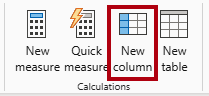

2. In the formula bar, type the following (or copy from the snippets file), and then press **Enter**:
> The formula uses the date’s year value but adds one to the year value when the month is after June. That’s how fiscal years at Adventure Works are calculated.

```dax
Year =
"FY" & YEAR('Date'[Date]) + IF(MONTH('Date'[Date]) > 6, 1)
```
3. Use the snippets file definitions to create the following two calculated columns for the `Date` table:
    * `Quarter`
    * `Month`
4. Verify the new columns have been added.

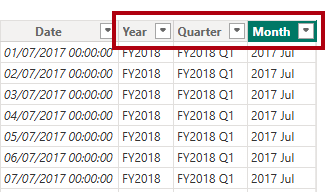

5. To validate the calculations, switch to **Report view**.
6. To create a new report page, select the plus icon next to **Page 1**.

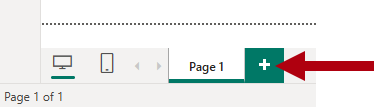

7. To add a matrix visual to the new report page, in the Visualizations pane, select the matrix visual type.
> Tip: You can hover the cursor over each icon to reveal a tooltip describing the visual type.

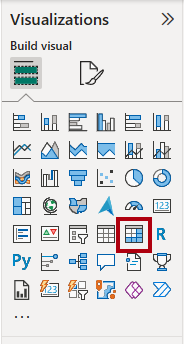

8. In the **Data** pane, from inside the `Date` table, drag the `Year` field into the **Rows** well.

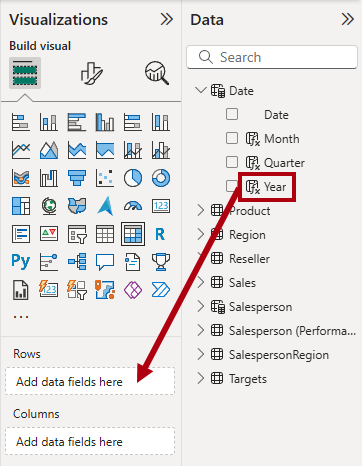

9. Drag the `Month` field into the **Rows** well, directly beneath the `Year` field.
10. At the top-right of the matrix visual (or bottom, depending on the location of the visual), select the forked-double arrow icon (which will expand all years down one level).

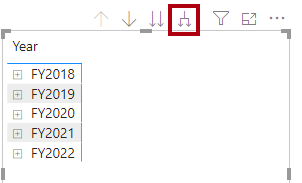

11. Notice that the years expand to months, and that the months are sorted alphabetically rather than chronologically.

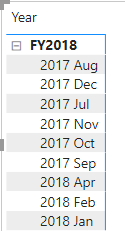

> By default, text values sort alphabetically, numbers sort from smallest to largest, and dates sort from earliest to latest.

12. To customize the `Month` field sort order, switch to **Table view**.
13. Add the `MonthKey` column to the `Date` table.

```dax
MonthKey =
(YEAR('Date'[Date]) * 100) + MONTH('Date'[Date])
```
> This formula computes a numeric value for each year/month combination.

14. In **Table view**, verify that the new column contains numeric values (for example, 201707 for July 2017, and so on).

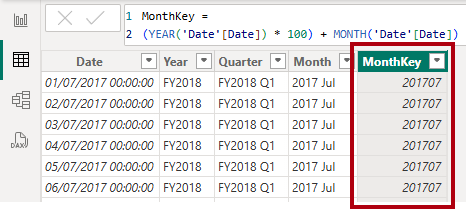

15. Switch back to **Report view**.
16. In the **Data** pane, select the `Month` field.
17. On the **Column Tools** contextual ribbon, from inside the **Sort** group, select **Sort by Column**, and then select **MonthKey**.

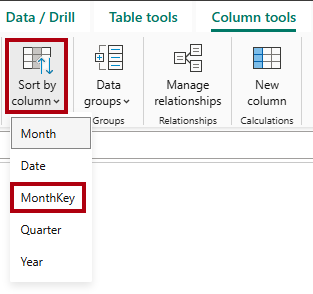

18. In the matrix visual, notice that the months are now chronologically sorted.

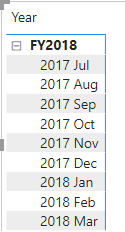

#### Complete the Date table
In this task, you’ll complete the design of the `Date` table by hiding a column and creating a hierarchy. You’ll then create relationships to the `Sales` and `Targets` tables.
1. Switch to **Model view**.
2. In the `Date` table, hide the `MonthKey` column (set **Is Hidden** to *Yes*).
3. In the **Data** pane, select the `Date` table, right-click the `Year` column, and the select **Create hierarchy**.

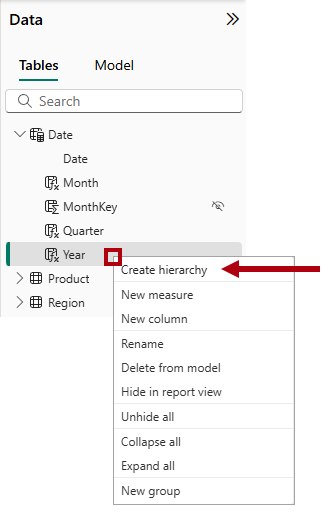

4. In the **Properties** pane, in the **Name** box, replace the value with *Fiscal*.

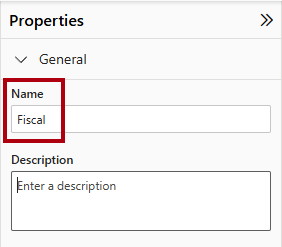

5. Two add levels to the hierarchy, in the **Hierarchy** dropdown list, select **Quarter** and then select **Month**, and then select **Apply Level Changes**.

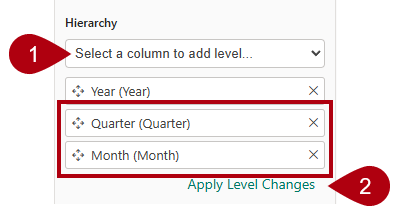

6. Create the following two model relationships:
    * `Date | Date` to `Sales | OrderDate`
    * `Date | Date` to `Targets | TargetMonth`
7. Hide the following two columns:
    * `Sales | OrderDate`
    * `Targets | TargetMonth`
#### Mark the Date table
In this task, you’ll mark the `Date` table as a date table.
1. Switch to **Report view**.
2. In the **Data** pane, select the `Date` table (not the `Date` field).
3. On the **Table Tools** contextual ribbon, from inside the **Calendars** group, select **Mark as Date Table**.

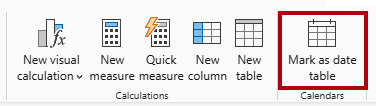

4. In the **Mark as a Date Table** window, slide the **Mark as a Date Table** property to *On*.
5. In the **Choose a date column** dropdown list, select **Date**.

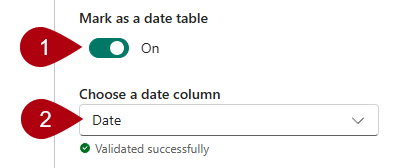

6. Select **Save**.
7. Save the Power BI Desktop file.
> Power BI Desktop now understands that this table defines date (time).

>This design approach for a date table is suitable when you don’t have a date table in your data source. If you have a data warehouse, it would be appropriate to load date data from its date dimension table rather than “redefining” date logic in your data model.

#### Create simple measures
In this task, you’ll create simple measures. Simple measures aggregate values in a single column or count rows of a table.
1. In **Report view**, on **Page 2**, from the **Data** pane, drag the `Sales | Unit Price` field into the matrix visual.

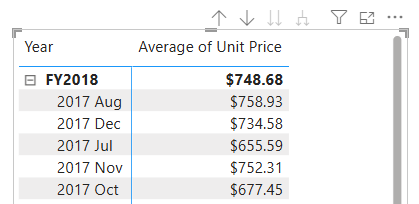

2. In the visual fields pane (located in the **Visualizations** pane), in the **Values** well, notice that `Unit Price` field is configured as **Average of Unit Price**.

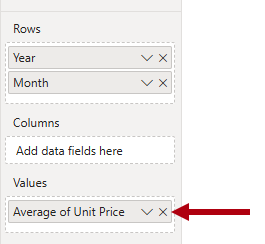

3. Select the down-arrow for **Average of Unit Price**, and then notice the available menu options.
> Visible numeric columns allow report authors at report design time to decide how column values will summarize (or not). However, it can result in inappropriate reporting.

> Some data modelers don’t like leaving things to chance, so they choose to hide these columns and instead expose aggregation logic defined in measures. It’s the approach you’ll now take in this lab.

4. To create a measure, in the **Data** pane, right-click the `Sales` table, and then select **New Measure**.
5. In the formula bar, add the following measure definition:

```dax
Avg Price =  
AVERAGE(Sales[Unit Price])
```
6. Add the `Avg Price` measure to the matrix visual, and notice that it produces the same result as the `Unit Price` column (but with different formatting).
7. In the **Values** well, open the context menu for the `Avg Price` field, and notice that it isn’t possible to change the aggregation technique.

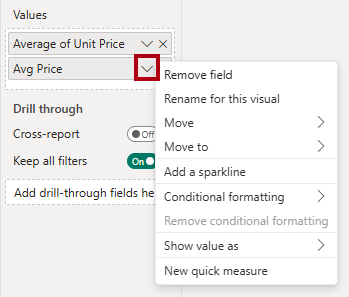

> It’s not possible to modify the aggregation behavior of a measure.

8. Use the snippets file definitions to create the following five measures for the `Sales` table:
    * `Median Price`
    * `Min Price`
    * `Max Price`
    * `Orders`
    * `Order Lines`

> The `DISTINCTCOUNT` function used in the `Orders` measure counts orders only once (ignoring duplicates). The `COUNTROWS` function used in the Order` Lines` measure operates over a table.

> In this case, the number of orders is calculated by counting the distinct `SalesOrderNumber` column values, while the number of order lines is simply the number of table rows (each row is a line of an order).

9. Switch to **Model view**, and then multi-select the four price measures: `Avg Price`, `Max Price`, `Median Price`, and `Min Price`.
10. For the multi-selection of measures, configure the following requirements:
    * Set the format to two decimal places.
    * Assign to a display folder named *Pricing* (use the **Display folder** property in the **Properties** pane).

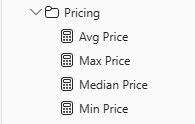

11. Hide the `Unit Price` column.
> The `Unit Price` column is no longer available to report authors. They must use the pricing measures you’ve added to the model. This design approach ensures that report authors won’t inappropriately aggregate prices, for example, by summing them.

12. Multi-select the `Order Lines` and `Orders` measures, and then configure the following requirements:
    * Set the format use the thousands separator.
    * Assign to a display folder named Counts.

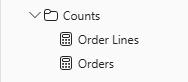

13. In **Report view**, in the **Values** well of the matrix visual, for **Average of Unit Price**, select **X** to remove it.

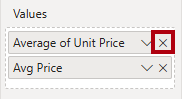

14. Increase the size of the matrix visual to fill the page width and height.
15. Add the following five measures to the matrix visual:
    * `Median Price`
    * `Min Price`
    * `Max Price`
    * `Orders`
    * `Order Lines`
16. Verify that the results look sensible and are correctly formatted.

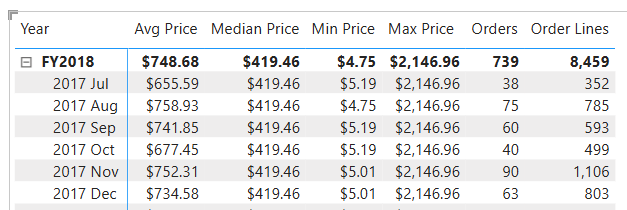

#### Create additional measures
In this task, you’ll create more measures that use more complex formulas.
1. In **Report view**, select **Page 1** and review the table visual of salespeople (on the right), noticing the total for the **Sum of Target** column.

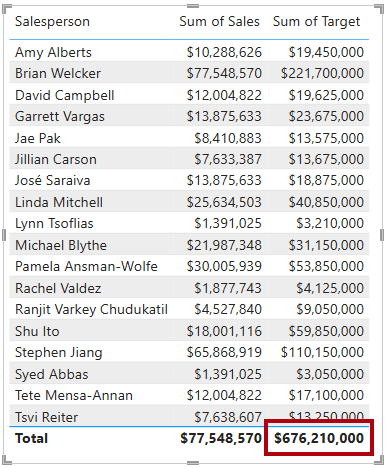

2. Select the table visual, and then in the **Visualizations** pane, remove **Sum of Target**.
3. Rename the `Targets | Target` column as *TargetAmount*.
> Tip: There are several ways to rename the column in Report view: In the Data pane, you can right-click the column, and then select Rename—or, double-click the column, or press F2.

4. Create the following measure on the `Targets` table:

```dax
Target =
IF(
    HASONEVALUE('Salesperson (Performance)'[Salesperson]),
    SUM(Targets[TargetAmount])
)
```
> The `HASONEVALUE` function tests whether a single value in the `Salesperson` column is filtered. When true, the expression returns the sum of target amounts (for just that salesperson). When false, `BLANK` is returned.

5. Format the `Target` measure for zero decimal places.
> Tip: You can use the Measure Tools contextual ribbon.

6. Hide the `TargetAmount` column.
> Tip: You can right-click the column in the Data pane, and then select Hide.

7. Notice that the `Targets` table now appears at the top of the list.

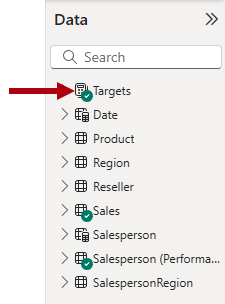

> Tables that comprise only visible measures are automatically listed at the top of the list.

8. Add the `Target` measure to the table visual.
9. Notice that the **Target** column total is now `BLANK`.

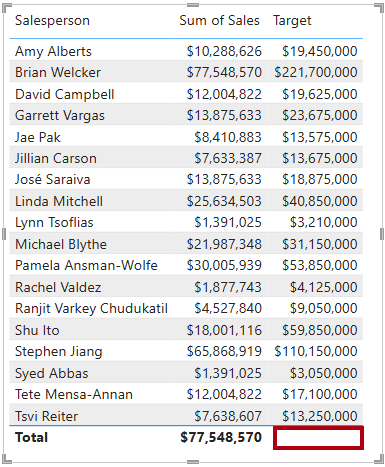

10. Use the snippets file definitions to create the following two measures for the `Targets` table:
    * `Variance`
    * `Variance Margin`
11. Format the `Variance` measure for zero decimal places.
12. Format the `Variance Margin` measure as percentage with two decimal places.
13. Add the `Variance` and `Variance Margin` measures to the table visual.
14. Resize the table visual so all columns and rows can be seen.

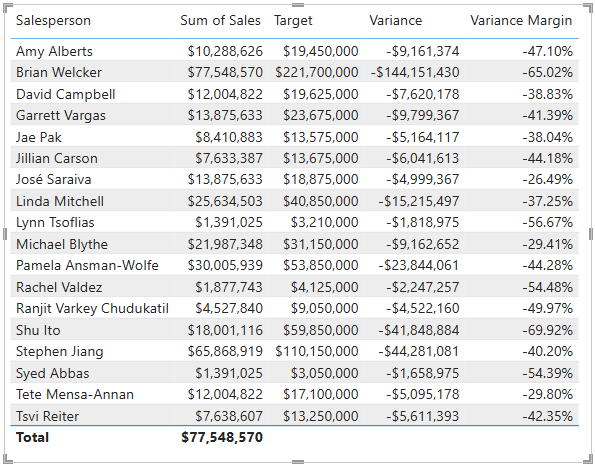

> While it appears all salespeople aren’t meeting target, remember that the table visual isn’t yet filtered by a specific time period. You’ll produce sales performance reports that filter by a user-selected time period in the Design a Report in Power BI Desktop lab.

15. Save the Power BI Desktop file.
#### Lab complete
You may choose to save your Power BI report, though it’s not necessary for this lab. In the next exercise, you’ll work with a pre-made starter file.
1. Navigate to the **File** menu in the top left corner and select **Save As**.
2. Select **Browse this device**.
3. Select the folder where you want to save the file and give it a descriptive name.
4. Select the **Save** button to save your report as a .pbix file.
5. If a dialog box appears prompting you to apply pending query changes, select **Apply**.
6. Close Power BI Desktop.

### **Check your knowledge**

#### 1. Which statement about calculated tables is true?

**A) Calculated tables increase the size of the semantic model.** \
B) Calculated tables are evaluated by using row context. \
C) Calculated tables are created in Power Query. \
D) Calculated tables can't include calculated columns.

#### 2. Which statement about calculated columns is true?

A) Calculated columns are created in the Power Query Editor window. \
**B) Calculated column formulas are evaluated by using row context.** \
C) Calculated column formulas can only reference columns from within their table. \
D) Calculated columns can't be related to noncalculated columns.

#### 3. Which statement about measures is correct?

A) Measures store values in the semantic model. \
B) Measures must be added to the semantic model to achieve summarization. \
C) Measures can reference columns directly. \
**D) Measures can reference other measures directly.**

## **Design semantic models for scale in Microsoft Fabric**

### **Introduction**

#### What is a Semantic Model?
A **Semantic Model** is the analytical layer that sits between raw data and reports.

It defines:

✅ Tables \
✅ Relationships \
✅ Measures \
✅ Calculations \
✅ Business logic \
✅ Security

Used by:
* Power BI Reports
* Dashboards
* Copilot
* Fabric AI Experiences
* External Analysis Tools
#### Why Design for Scale?
A model that works for:
> 10 Users | 100 MB Data

may struggle when it grows to:
> 1000 Users | 100+ GB Data

Challenges include:

❌ Slow queries \
❌ Long refresh times \
❌ Memory pressure \
❌ Complex maintenance \
❌ Poor AI performance
#### Main Design Areas
This module focuses on four major design decisions:
##### 1. Storage Mode
How data is stored and accessed.

Options:
* Import
* DirectQuery
* Direct Lake
* Composite Models
##### 2. Star Schema Design
How tables relate to one another.

Use:
> Fact Tables + Dimension Tables

instead of complex snowflake structures.
##### 3. Scalable Calculations
Choosing:

✅ Efficient measures \
✅ Appropriate DAX patterns \
✅ Minimal calculated columns
##### 4. Model Configuration
Settings that affect:

✅ Performance \
✅ Large datasets \
✅ Concurrency \
✅ External tools \
✅ AI workloads
#### Storage Modes
One of the most important scalability decisions.
##### Import Mode
Data is copied into the semantic model.

**Advantages**

✅ Fastest query performance \
✅ Excellent user experience \
✅ Richest DAX support

**Disadvantages**

❌ Requires refreshes \
❌ Model size limitations

**Best For**

Small and medium datasets.
##### DirectQuery
Queries source data in real time.

**Advantages**

✅ Always current \
✅ Minimal imported data

**Disadvantages**

❌ Slower queries \
❌ Depends on source performance

**Best For**

Very large datasets requiring real-time access.
##### Direct Lake (Fabric)
Fabric's preferred modern option.

**Advantages**

✅ Query lakehouse data directly \
✅ No import needed \
✅ High performance \
✅ Reduced duplication

**Best For**

Microsoft Fabric lakehouse analytics.
##### Composite Models
Mix storage modes.

Example:
> Import + DirectQuery

#### Star Schema Design
##### Recommended Model Structure
```
       DimCustomer
            |
DimDate -- FactSales -- DimProduct
            |
        DimRegion
```
##### Benefits
✅ Simpler design \
✅ Faster filtering \
✅ Better DAX \
✅ Better AI understanding \
✅ Easier maintenance
#### Fact Tables
Store:
* Sales
* Orders
* Revenue
* Quantity

Answer:
* How much?
* How many?

#### Dimension Tables
Store:
* Customer
* Product
* Date
* Region

Answer:
* vWho?
* What?
* When?
* Where?
#### Why Star Schema Helps Scale
##### Better Query Performance
Power BI can navigate relationships efficiently.
##### Better DAX Performance
Measures are simpler.
##### Better AI Experiences
Copilot understands:
> Sales → Customer → Product

relationships more clearly.
#### Scalable Calculation Design
##### Prefer Measures
Use:
```dax
Revenue =
SUM(Sales[Sales Amount])
```
instead of:
```dax
Revenue Column =
...
```
##### Why?
Measures:

✅ Not stored \
✅ Smaller model \
✅ Better memory usage \
✅ Faster refreshes
##### Minimize Calculated Columns
Calculated columns:

❌ Increase model size \
❌ Increase refresh duration \
❌ Consume memory

Use only when required.
#### Calculation Best Practice
##### Good
```dax
Revenue =
SUM(Sales[Sales Amount])

Profit =
[Revenue] - [Cost]
```
##### Less Optimal
Store:
* Revenue Column
* bProfit Column
* Margin Column

for every row.
#### Reusable Measures
Create business measures once.

Examples:
* Revenue
* Profit
* Profit Margin
* YTD Revenue

Benefits:

✅ Consistency \
✅ Easier maintenance \
✅ Better governance
#### Large Model Considerations
As models grow:
##### Monitor
✅ Model size \
✅ Refresh duration \
✅ Query speed \
✅ Memory usage
##### Reduce
❌ Unused columns \
❌ Unused tables \
❌ Excess calculated columns
#### External Tool Access
Scaled semantic models often connect to:
* Power BI
* Excel
* SSMS
* Tabular Editor
* DAX Studio

Design should support multiple consumers without performance degradation.
#### Concurrency
Concurrency means:
> Many users querying simultaneously

Example:
> 100 report users

running queries at the same time.

Scalable models should:

✅ Handle many concurrent queries \
✅ Maintain acceptable response times
#### AI and Semantic Models
Copilot and AI place additional demands on models.

AI performs best when models have:

✅ Current data \
✅ Clear relationships \
✅ Star schema design \
✅ Descriptive names \
✅ Well-written measures
##### Good Example
```
FactSales
DimCustomer
Revenue
Profit Margin
```
##### Poor Example
```
Table1
Column2
Measure3
```
AI struggles to interpret unclear metadata.
#### Typical Enterprise Fabric Architecture
> Lakehouse → Warehouse → Semantic Model → Measures → Power BI → Copilot → Business Users

#### Design Goals
A scalable semantic model should be:

✅ Fast \
✅ Maintainable \
✅ Understandable \
✅ Memory-efficient \
✅ AI-friendly \
✅ Easy to extend
#### Exam Quick Facts
✅ Semantic models power:
* Reports
* Dashboards
* Copilot
* AI experiences

✅ Four major design decisions:
1. Storage Mode
2. Star Schema
3. Calculation Design
4. Model Configuration

✅ Recommended schema:
> Fact + Dimensions

✅ Measures scale better than calculated columns \
✅ Calculated columns increase model size \
✅ Direct Lake is Fabric's preferred large-scale model approach \
✅ Star schemas improve:
* Performance
* Simplicity
* AI understanding

✅ Good semantic models support:
* Large datasets
* Concurrent users
* External tools
* AI workloads
#### Memory Trick
> Scale = Storage + Schema + Calculations + Settings

Or:
> Store Smart → Model Smart → Calculate Smart → Scale Smart ⭐

### **Choose a storage mode**

#### Why Storage Mode Matters
Storage mode determines:

✅ Query performance \
✅ Data freshness \
✅ Model size \
✅ Scalability \
✅ AI/Copilot performance

It is the **first design decision** when creating a semantic model.
#### Storage Modes in Fabric
There are 4 storage modes:
1. Direct Lake ⭐ (Default)
2. Import
3. DirectQuery
4. Composite
#### 1. Direct Lake (Recommended)
##### What is Direct Lake?
Direct Lake reads Delta tables directly from OneLake.

Unlike Import:

❌ No data copy

Unlike DirectQuery:

❌ No SQL translation

Instead:
> OneLake Delta Files → Direct Lake → Semantic Model

##### Major Benefits
**Near Real-Time Data**

Changes in Delta tables become available immediately.

✅ No scheduled refresh required

**High Performance**

Combines:
> Import Speed + DirectQuery Freshness

##### Fabric-Native
Best choice for:
* Lakehouses
* Warehouses
* OneLake
##### Direct Lake Architecture
> Delta Tables → OneLake → Direct Lake → Power BI → Copilot

##### Large Semantic Model Support
Direct Lake automatically enables:

Large Semantic Model Format

Benefits:

✅ Removes 10-GB limit \
✅ Supports Query Scaleout \
✅ Supports XMLA Read/Write
##### Exam Tip
For Direct Lake:

✅ Automatically enabled \
❌ No manual configuration required
#### Direct Lake Connection Options
##### Option 1: OneLake Tables
Connect directly to:
* Lakehouse Tables
* Warehouse Tables

**Best For**

✅ Single data source \
✅ Simpler architecture \
✅ Most scenarios
##### Option 2: SQL Analytics Endpoint
Connect via SQL endpoint.

**Benefits**

✅ Views \
✅ Cross-database queries \
✅ SQL-based security \
✅ Governance requirements
##### Exam Tip
Use SQL Analytics Endpoint when:
* Views
* Cross-Database Queries
* SQL Security

are required.
#### Direct Lake Fallback
Sometimes Direct Lake cannot execute a query.

Examples:

✅ Memory pressure \
✅ Unsupported operations \
✅ Complex DAX

Then Fabric falls back to DirectQuery mode.
#### Fallback Options
##### Allow Fallback
> Direct Lake → If Needed → DirectQuery

User still receives results.

**Benefit**

✅ More reliable \
✅ Better user experience
##### Disallow Fallback
> Direct Lake Only

If unsupported:
> `Error Returned`

**Benefit**

✅ Consistent performance expectations

**Exam Recommendation**

Start with:

✅ Allow Fallback

Monitor:

✅ Which queries trigger it

Optimize later.
#### 2. Import Mode
##### What is Import Mode?
Copies data into the model.
> Source → Imported Data → In-Memory Storage

##### Benefits
**Fastest Query Performance**
* Queries run against memory.
* Extremely fast

**Rich Feature Support**
* Supports almost all Power BI features.

##### Drawbacks
**Data Becomes Stale**
* Requires refresh.
      > Refresh → Updated Data

**Storage Consumption**
* Data is duplicated.
#### Use Import When
✅ External sources \
✅ On-prem databases \
✅ APIs \
✅ Maximum performance needed \
✅ Real-time not required
#### Import Best Practices\
✅ Use views \
✅ Remove unnecessary columns \
✅ Use proper data types \
✅ Reduce model size
#### 3. DirectQuery
##### What is DirectQuery?
Queries source systems in real time.
> Report → Source Database

##### Data Storage
❌ No data stored in model
##### Benefits
**Real-Time Data**
* Always current.

**Handles Very Large Datasets**
* No import needed.
##### Drawbacks
**Slower Performance**

Every interaction:
> Visual Click → Database Query

**Source Dependency**

If database is slow:

✅ Report becomes slow
#### Use DirectQuery When
✅ Real-time reporting is required \
✅ External data is too large \
✅ Governance requires data to remain at source
#### 4. Composite Mode
##### What is Composite Mode?
Combines storage modes.

Example:
> Direct Lake + Import

or
> Import + DirectQuery

##### Benefits
**Hybrid Architecture**
* Each table uses the best storage mode.

Example
> Fact Sales → Direct Lake \
> Reference Table → Import

#### Use Composite When
✅ Fabric + external sources \
✅ Mixed freshness requirements \
✅ Hybrid analytics
#### Storage Mode Comparison
| Mode        | Data Location | Speed             | Freshness      | Best For                 |
| ----------- | ------------- | ----------------- | -------------- | ------------------------ |
| Direct Lake | OneLake       | Fast              | Near Real-Time | Fabric (default)         |
| Import      | Model Memory  | Fastest           | Refresh-based  | External sources         |
| DirectQuery | Source System | Depends on source | Real-Time      | Very large external data |
| Composite   | Mixed         | Mixed             | Mixed          | Hybrid solutions         |

#### Which Storage Mode Should You Choose?
##### Data in Fabric?
✅ Yes → Use Direct Lake

##### Data Outside Fabric?
**Need best performance?**

✅ Yes → Use Import

**Need Real-Time Data?**

✅ Yes → Use DirectQuery

**Need Multiple Sources?**

✅ Yes → Use Composite

#### Storage Modes and AI
Storage mode affects:

✅ Copilot \
✅ Fabric AI \
✅ Data Agents
#### Direct Lake Advantage
Because data stays current:
> Updated Delta Table → Updated Semantic Model → Updated Copilot Answers

No refresh delay.
#### Exam Quick Facts
✅ Direct Lake is the default storage mode in Fabric \
✅ Direct Lake reads Delta tables directly from OneLake \
✅ Direct Lake combines:
* Import performance
* DirectQuery freshness

✅ Direct Lake automatically enables:
* Large Semantic Models
* Query Scaleout
* XMLA Read/Write

✅ Direct Lake connection types:
* OneLake Tables
* SQL Analytics Endpoint

✅ DirectQuery stores no data in the model \
✅ Import mode provides the fastest query performance \
✅ DirectQuery provides the freshest data \
✅ Composite models combine storage modes
#### Memory Trick
> Fabric → Direct Lake First

Think:
* Direct Lake = Default
* Import = Fastest
* DirectQuery = Real-Time
* Composite = Hybrid

⭐ Exam Rule: 
> *If the question asks "What storage mode should you start with in Microsoft Fabric?"* 

→ Direct Lake.

### **Design star schema for semantic models**

#### What is a Star Schema?
A **Star Schema** is the recommended design pattern for semantic models.

It consists of:
> Fact Tables + Dimension Tables

Example:
```
       DimCustomer
            |
DimDate -- FactSales -- DimProduct
            |
        DimRegion
```
#### Why Use a Star Schema?
Benefits:

✅ Simpler relationships \
✅ Faster queries \
✅ Easier DAX \
✅ Better scalability \
✅ Better Copilot and AI performance \
✅ Easier maintenance
#### Fact Tables
#### Purpose
Store measurable business events.

Examples:
* Sales
* Orders
* Inventory
* Shipments
##### ontains
Measures such as:
* Sales Amount
* Quantity
* Cost
* Profit
##### Answers
* How much?
* How many?
#### Dimension Tables
##### Purpose
Provide descriptive context.

Examples:
* Customer
* Product
* Date
* Category
* Region
##### Contains
Attributes such as:
* Customer Name
* Product Category
* City
* Fiscal Year
##### Answers
* Who?
* What?
* When?
* Where?
#### Star Schema and AI
Copilot and AI tools work best when relationships are clear.

Example:
> Revenue → Customer → Region

is easy for AI to understand.
##### Poor Design
* Circular Relationships
* Multiple Ambiguous Paths
* Snowflake Complexity

can confuse:

❌ Users \
❌ DAX \
❌ Copilot
#### Relationships in a Star Schema
The most common relationship is:
##### One-to-Many
> Dimension (One) → Fact (Many)

Example:
> One Product → Thousands of Sales Rows

##### Example
```
DimProduct[ProductKey] → FactSales[ProductKey]
```
##### Best Practice
Configure filtering:
> Dimension → Fact

Only.
##### Exam Memory
✅ One-to-Many is the standard star schema relationship.
#### Filter Direction
##### Single Direction (Recommended)
> Dimension → Fact

Example:
> Product → Sales

Filtering:
> Product Category = Bikes

filters Sales.
##### Benefits
✅ Predictable results \
✅ Better performance \
✅ Easier troubleshooting
##### Bi-Directional Filtering
> Dimension ↔ Fact

Filters flow both ways.
##### Use Sparingly
Only when necessary:

✅ Certain many-to-many scenarios \
✅ Special reporting requirements
##### Risks
❌ Slower queries \
❌ Unexpected results \
❌ Ambiguous filter propagation
##### Exam Tip
Default recommendation:

✅ Single-direction filters
#### Many-to-Many Relationships
##### Problem
Neither side contains unique values.

Example:
> Customer ↔ Account

A customer can have:
> Multiple Accounts

An account can belong to:
> Multiple Customers

##### Solution: Bridge Table
Example:
> Customer → CustomerAccountBridge → Account

##### Relationship Pattern
> One-to-Many + One-to-Many

instead of direct many-to-many.
#### Direct Lake Relationship Design
In Direct Lake, relationships perform best when:
##### 1. Low Cardinality Keys
Example:

✅ `ProductKey` \
✅ `CustomerKey`

Avoid:

❌ Highly unique text columns
##### 2. Referential Integrity Exists
Every fact row should match a dimension row.

Example:
> `CustomerKey` in Fact exists in `Customer` Dimension

**Benefit**

Engine can use:
```
INNER JOIN
```
instead of:
```
LEFT OUTER JOIN
```
for better performance.
##### 3. Indexed Columns
Relationship columns should be optimized in Delta tables.
#### Referential Integrity
##### What Is It?
Every foreign key has a valid matching dimension row.

Example:
```
FactSales.CustomerKey = 100
```
must exist in:
```
DimCustomer.CustomerKey = 100
```
#### Assume Referential Integrity
Available in:

✅ Direct Lake \
✅ DirectQuery
##### Benefit
Allows:
```
INNER JOIN
```
which improves performance.
##### Warning
If integrity is broken:
> Missing Rows

may disappear from results.
##### Exam Tip
Enable only when confident all keys match.
#### Active and Inactive Relationships
A common exam topic.
##### Rule
Only:
> ONE ACTIVE RELATIONSHIP

between two tables.
##### Example
Sales table contains:
* `Order Date`
* `Ship Date`

Both relate to:
* `Date Table`

Only one can be:

✅ Active

The other becomes:

❌ Inactive
#### `USERELATIONSHIP`
Used to activate an inactive relationship in a measure.

Example:
```dax
Shipped Amount =
CALCULATE(
    SUM(Sales[Amount]),
    USERELATIONSHIP(
        Sales[ShipDate],
        'Date'[Date]
    )
)
```
##### Purpose
Analyze data using:
> `Ship Date`

instead of:
> `Order Date`

without changing model relationships.
##### Exam Tip
Remember:
```dax
USERELATIONSHIP()
```
is used with inactive relationships.
#### Snowflake Schema
##### What is Snowflake?
Normalized dimension design.

Example:
> Category → Subcategory → Product → Fact Sales

##### Structure
**Multiple Related Dimensions**

instead of:

**Single Product Dimension**
#### Option 1: Flatten Snowflake (Recommended)
Convert:
* Category
* Subcategory
* Product

into:
```
DimProduct
```
##### Benefits
✅ Fewer tables \
✅ Fewer relationships \
✅ Faster queries \
✅ Easier DAX \
✅ Better AI understanding
##### Exam Recommendation
Most Fabric semantic models should:

✅ Flatten dimensions into a star schema.
#### Option 2: Preserve Snowflake
Keep normalized structure.

Use when:
##### 1. Large Hierarchies
Too many repeated attributes.
##### 2. Shared Subdimensions
Example:
> Category

used by:
* Sales Fact
* Inventory Fact
##### 3. Row-Level Security Requirements
Security managed at hierarchy levels.
#### Snowflake Relationship Rules
If preserved:

Filters should flow:
> Category → Subcategory → Product → Fact

using single-direction filtering.
#### Cross-Source Relationships
Fabric supports:
> Lakehouse + Warehouse + External Sources

inside one model.
#### Composite Models
Used when tables come from different sources.

Example:
> Fact Sales → Direct Lake \
> Reference Table → Import

##### Good Scenarios
✅ Lakehouse + Warehouse \
✅ Direct Lake + Import \
✅ External Reference Data \
✅ Streaming + Historical Data
#### Storage Modes and Relationships
| Storage Mode | Relationship Considerations   |
| ------------ | ----------------------------- |
| Direct Lake  | Best Fabric performance       |
| Import       | Fully cached relationships    |
| DirectQuery  | Depends on source performance |
| Composite    | Cross-source relationships    |

#### Star Schema Best Practices
✅ Fact tables store measurements \
✅ Dimension tables store attributes \
✅ One-to-many relationships \
✅ Single-direction filtering \
✅ Maintain referential integrity \
✅ Use `USERELATIONSHIP` for inactive relationships \
✅ Flatten snowflake dimensions whenever possible \
✅ Use bridge tables for many-to-many relationships
#### Exam Quick Facts
✅ Star schema = Fact + Dimensions \
✅ Fact tables contain measures \
✅ Dimension tables contain descriptive attributes \
✅ Most common relationship:
> One-to-Many

✅ Recommended filter direction:
> Dimension → Fact

✅ Use bridge tables for many-to-many relationships \
✅ Assume Referential Integrity enables `INNER JOIN` behavior \
✅ Only one active relationship allowed between two tables \
✅ Use:
```dax
USERELATIONSHIP()
```
to activate inactive relationships

✅ Flatten snowflake dimensions whenever possible \
✅ Composite models support cross-source relationships
#### Memory Trick
> Star Schema = Facts in the Center, Dimensions Around Them ⭐

And remember the exam rule:
* Dimension → Fact
* One-to-Many
* Single Direction

This is the default and recommended semantic model design in Microsoft Fabric.

### **Design scalable calculations**

#### Why Calculation Design Matters
A model with:
> 10 Measures

can survive poor design.

A model with:
> 200+ Measures \
> 100+ Reports \
> Many Developers

cannot.

Poor calculation design causes:

❌ Duplicate logic \
❌ Slow queries \
❌ Maintenance nightmares \
❌ Inconsistent business metrics \
❌ Confusing Copilot results
#### Three Key Scalability Patterns
This unit focuses on:
1. Calculation Groups
2. DAX Readability & Maintainability
3. Aggregations
#### 1. Calculation Groups
##### What Are Calculation Groups?
A **Calculation Group** allows you to define a calculation pattern once and apply it to many measures.
##### Problem Without Calculation Groups
Assume:
> 50 Measures

Need:
```
YTD
QTD
MTD
```
for each.

Result:
> 50 × 3 = 150 additional measures

Add:
```
Prior Year
Growth %
Variance
```
and you can easily exceed:
> 250+ measures

##### Solution: Calculation Groups
Create one calculation group containing:
* Year-to-Date
* Quarter-to-Date
* Month-to-Date

Then use it for every measure.
##### Example
**YTD Item**
```dax
CALCULATE(
    SELECTEDMEASURE(),
    DATESYTD('Date'[Date])
)
```
**QTD Item**
```dax
CALCULATE(
    SELECTEDMEASURE(),
    DATESQTD('Date'[Date])
)
```
**MTD Item**
```dax
CALCULATE(
    SELECTEDMEASURE(),
    DATESMTD('Date'[Date])
)
```
#### `SELECTEDMEASURE()`
Most important calculation-group concept.
##### Purpose
Returns:
> Current Measure

being evaluated.

Examples:
> Revenue \
> Profit \
> Quantity

The same calculation item can work for all of them.
##### Exam Tip
`SELECTEDMEASURE()`

is heavily associated with:

✅ Calculation Groups
#### Benefits of Calculation Groups
✅ Fewer measures \
✅ Easier maintenance \
✅ Consistent business logic \
✅ Smaller semantic model \
✅ Easier AI interpretation
#### When to Use Calculation Groups
Use when:

✅ 3 or more measures require identical logic

Common scenarios:
##### Time Intelligence
```
YTD
QTD
MTD
```
##### Currency Conversion
```
USD
EUR
GBP
```
##### Variance Analysis
```
Actual
Budget
Variance
Variance %
```
#### Dynamic Format Strings
##### Purpose
Change formatting automatically based on context.

Example:
##### Currency
`$1,250.00`
##### Percentage
`12.5%`
##### Example
`"0.0%"`

used in a:

`YoY %`

calculation item.
##### Benefit
Avoids creating:
```
Revenue %
Profit %
Margin %
```
formatted measures separately.
#### 2. DAX Readability Discipline
##### Why It Matters
In enterprise models:
* Hundreds of Measures
* Multiple Developers
* Years of Maintenance

Readability becomes critical.
#### Variables (VAR)
##### Purpose
Store intermediate calculations.
##### Example
```dax
Profit Margin =
VAR TotalRevenue =
    SUM(Sales[Revenue])

VAR TotalCost =
    SUM(Sales[Cost])

VAR ProfitAmount =
    TotalRevenue - TotalCost

RETURN
    DIVIDE(
        ProfitAmount,
        TotalRevenue
    )
```
#### Benefits of Variables
✅ Easier to read \
✅ Easier debugging \
✅ Reuse calculations \
✅ Better performance
##### Without Variables
You may repeat:
```dax
SUM(Sales[Revenue])
```
multiple times.
##### With Variables
* Calculate once.
* Reuse many times.
##### Exam Tip
```dax
VAR
RETURN
```
is a recommended DAX pattern.
#### Naming Conventions
A very common enterprise design principle.
##### Measure Naming
**Good**
> Total Sales \
> Profit Margin \
> YoY Revenue Growth

**Bad**
> `Measure1` \
> `Sales_Calc_Rev` \
> `Test_v2`

##### Variable Naming
**Good**
```dax
TotalRevenue
ProfitAmount
```
**Bad**
```
x
temp
value1
```
##### Calculation Group Names
**Good**
> Year-to-Date \
> Quarter-to-Date

**Bad**
```
DATESYTD Wrapper
Calc Item 1
```
#### AI & Naming
Good naming improves:

✅ Copilot \
✅ AI-generated insights \
✅ Natural language queries

Example:
> YoY Revenue Growth

is easier for AI to understand than:
```
Calc7_v2
```
#### Aggregation Functions vs Iterator Functions
##### Aggregation Functions
Operate on a single column.

Example:
```dax
SUM(Sales[Amount])
```
##### Benefits
✅ Faster \
✅ More efficient \
✅ Preferred when possible
##### Iterator Functions
Operate row-by-row.

Examples:
```dax
SUMX
AVERAGEX
MAXX
```
##### Example
```dax
SUMX(
    Sales,
    Sales[Quantity]
        *
    Sales[Unit Price]
)
```
##### Benefits
✅ More flexible \
✅ Multiple columns \
✅ Complex logic
##### Drawback
❌ Slower on large tables
##### Exam Rule
**Use: Aggregation Functions**
* when summarizing one column.

**Use Iterator Functions**
* when row-level calculations are required.
#### Information Functions
Useful for defensive DAX.
##### `HASONEVALUE()`
Checks whether exactly one value exists.

Example:
```dax
HASONEVALUE(
    Customer[CustomerID]
)
```
##### `ISBLANK()`
Checks for blank values.

Example:
```dax
IF(
    ISBLANK([Revenue]),
    0
)
```
##### `ISINSCOPE()`
* Checks whether a column is currently being grouped.
* Useful in matrix visuals and hierarchies.
#### Defensive Measure Example
```dax
Sales per Customer =
IF(
    HASONEVALUE(
        Customer[CustomerID]
    ),
    DIVIDE(
        SUM(Sales[Amount]),
        1
    ),
    DIVIDE(
        SUM(Sales[Amount]),
        DISTINCTCOUNT(
            Sales[CustomerID]
        )
    )
)
```
#### Why Use Defensive Patterns?
Protects measures from:

✅ Unexpected filters \
✅ Different reports \ 
✅ AI-generated queries \
✅ New report scenarios
#### 3. Aggregations
##### What Are Aggregations?
Aggregation tables store:
> Precalculated Summaries

at higher levels.
##### Example
Instead of:
> 500 Million Sales Rows

create:
> Monthly Sales by Region

aggregation table.
##### Benefits
Queries can hit:
> Small Summary Table

instead of:
> Massive Fact Table

Result:

✅ Faster queries \
✅ Less resource usage \
✅ Better scalability
#### When to Consider Aggregations
Use when:

✅ Fact table contains millions of rows \
✅ Most reports summarize data \
✅ Query performance becomes an issue
##### Typical Example
Store:
> Monthly Sales

instead of forcing scans over:
> Daily Transactions

every time.
#### Aggregations in Import Mode
Stored as:
> Hidden Aggregation Tables

Query engine automatically uses them.
#### Aggregations in Direct Lake
Direct Lake handles large volumes efficiently already.

Therefore:

✅ Add aggregations only when monitoring proves they're needed.
##### Exam Tip
Direct Lake generally requires fewer aggregation tables than Import models.
#### Scalable Calculation Best Practices
✅ Use Calculation Groups for repetitive logic \
✅ Use `SELECTEDMEASURE()` inside Calculation Groups \
✅ Use `VAR` and `RETURN` \
✅ Create clear naming conventions \
✅ Use aggregation functions when possible \
✅ Minimize iterators on large datasets \
✅ Use `HASONEVALUE` and `ISBLANK` defensively \
✅ Add aggregation tables when fact tables become very large
#### Exam Quick Facts
✅ Calculation Groups reduce measure proliferation \
✅ Calculation Groups rely on:
```dax
SELECTEDMEASURE()
```
✅ Common Calculation Group use cases:
* YTD
* QTD
* MTD
* Currency Conversion
* Variance Analysis

✅ Dynamic Format Strings adjust formatting automatically \
✅ `VAR` improves readability and performance \
✅ Aggregation functions are generally faster than iterators \
✅ Iterator functions:
* `SUMX`
* `AVERAGEX`
* `MAXX`

✅ Information functions:
* `HASONEVALUE`
* `ISBLANK`
* `ISINSCOPE`

✅ Aggregations store precalculated summaries \
✅ Consider aggregations when fact tables reach millions of rows
#### Memory Trick
> Scale Calculations = Reuse + Readability + Aggregations

or
>Calculation Groups → Variables → Aggregations

⭐⭐ Most important exam concept:
> Calculation Group → `SELECTEDMEASURE()`

They almost always appear together in Microsoft Fabric and Power BI semantic model questions.

### **Configure settings for scale**

#### Why These Settings Matter
After designing:

✅ Storage Mode \
✅ Star Schema \
✅ Measures

You must configure settings that support:
* Large datasets
* High concurrency
* External tools
* Direct Lake optimization
* Enterprise deployments

These settings determine whether the model can scale from:
> Small Team → Enterprise Analytics

#### 1. Large Semantic Model Storage Format
##### What Does It Do?
Increases semantic model size capacity.

Without it:
> 10 GB Upload Limit

With it:
> Model Can Grow Beyond 10 GB

(subject to Fabric capacity limits)
##### Why It Matters
Large enterprise models often exceed:
> 10 GB

especially with:
* Large fact tables
* Incremental refresh
* Historical data
##### Direct Lake Behavior
**Important Exam Fact**

Direct Lake models:

✅ Automatically enable Large Semantic Model Storage Format.

No manual setup required.
##### Import Models
Must be enabled manually.
##### Enable It When
✅ Model exceeds 10 GB \
✅ Using XMLA Read/Write \
✅ Using Query Scaleout \
✅ Using Incremental Refresh
##### Exam Memory
Large Semantic Models are required for:
> XMLA \
> Query Scaleout \
> Large Datasets

#### 2. XMLA Endpoint Read/Write
##### What is XMLA?
* XMLA provides external access to semantic models.
* Allows enterprise development tools to connect.
##### Common Tools
**Tabular Editor**

Used for:

✅ Model development \
✅ Calculation groups \
✅ Advanced modeling

**DAX Studio**

Used for:

✅ DAX debugging \
✅ Query tuning \
✅ Performance analysis

**ALM Toolkit**

Used for:

✅ Deployment \
✅ Versioning \
✅ CI/CD
#### Requirements
Must have:

✅ Large Semantic Model Storage Format enabled
#### Benefits
Enables:

✅ Enterprise development workflows \
✅ Source control integration \
✅ Automated deployments
##### Exam Tip
At enterprise scale:
> XMLA Endpoint

becomes extremely important.
#### 3. Query Scaleout
##### What Problem Does It Solve?
Many users running queries simultaneously.

Example:
> 500 Users

connecting to:
> One Semantic Model

##### Without Scaleout
> Single Model Instance → Performance Bottleneck

##### With Scaleout
> Primary Model → Multiple Read Replicas → Shared Query Load

#### How It Works
Creates:
> Read-Only Replicas

of the semantic model.

User queries are distributed across replicas.
#### Benefits
✅ Higher concurrency \
✅ Better response times \
✅ Reduced bottlenecks \
✅ Enterprise scalability
#### Important Behavior
After refresh:
> Primary Model Refreshes → Replicas Synchronize

There may be a small delay before replicas reflect refreshed data.
#### Requirements
Query Scaleout requires:

✅ Large Semantic Model Storage Format
#### Enable Query Scaleout When
✅ Hundreds of users \
✅ Peak-time slowdowns \
✅ Heavy dashboard usage \
✅ Supported Fabric capacity
##### Exam Memory
> Large Semantic Model → Required For → Query Scaleout

#### 4. Direct Lake Fallback
##### Why Does Fallback Exist?
Some Direct Lake queries cannot execute directly.

Examples:

✅ Memory limitations \
✅ Unsupported operations \
✅ Complex queries
##### Allow Fallback (Default)
Behavior:
> Direct Lake → Cannot Execute → DirectQuery

Query still works.
##### Benefits
✅ Better user experience \
✅ More reliable results 
##### Disallow Fallback
Behavior:
> Direct Lake → Cannot Execute → Error

##### Benefits
✅ Predictable performance \
✅ Strict Direct Lake enforcement
#### Recommendation
For most production models:

✅ Allow Fallback

Then:

✅ Identify fallback queries

✅ Optimize them
##### Exam Tip
Default recommendation:
> Allow Fallback

#### 5. OneLake Integration
##### What Does It Do?
Exposes semantic model data to other Fabric services.
##### Consumers
✅ Notebooks \
✅ Pipelines \
✅ Data Engineering \
✅ Data Science \
✅ Fabric Services
##### Benefit
Turns a semantic model into:
> Shared Curated Data Source

instead of only a reporting layer.
##### Example
> Lakehouse → Semantic Model → Notebook Reads Data

without rebuilding the logic.
#### Enable OneLake Integration When
✅ Data scientists need model data \
✅ Data engineers need curated data \
✅ Semantic model becomes a reusable business layer
#### OneLake Integration Limitation
Currently supports:

✅ Import Tables

Does NOT export:

❌ Direct Lake tables \
❌ DirectQuery tables \
❌ Measures \
❌ Calculation Groups
##### Why?
Direct Lake tables already exist in OneLake.
#### Enterprise Configuration Flow
> Large Semantic Model → XMLA Endpoint → Query Scaleout → High-Concurrency Analytics

#### Recommended Configuration Strategy
##### Direct Lake Model
✅ Large Semantic Model (automatic) \
✅ Allow Fallback \
✅ Consider Query Scaleout \
✅ Consider OneLake Integration
##### Enterprise Import Model
✅ Enable Large Semantic Model \
✅ Enable XMLA Read/Write \
✅ Consider Query Scaleout \
✅ Consider OneLake Integration
#### Settings Decision Table
| Setting                             | Default             | Enable When                       |
| ----------------------------------- | ------------------- | --------------------------------- |
| Large Semantic Model Storage Format | Off (Import models) | Model >10GB, XMLA, Query Scaleout |
| XMLA Read/Write                     | Read-only           | External tool development         |
| Query Scaleout                      | Off                 | High concurrency                  |
| Direct Lake Fallback                | Allowed             | Keep allowed for most workloads   |
| OneLake Integration                 | Off                 | Downstream Fabric reuse           |

#### Dependency Relationships (Exam Favorite)
> Large Semantic Model Storage Format → Required For: → XMLA Endpoint/Query Scaleout

#### Exam Quick Facts
✅ Direct Lake automatically enables Large Semantic Model Storage Format \
✅ Large Semantic Model removes the 10 GB upload limitation \
✅ XMLA Endpoint enables:
* Tabular Editor
* DAX Studio
* ALM Toolkit

✅ Query Scaleout uses read-only replicas \
✅ Query Scaleout requires Large Semantic Model Storage Format \
✅ Direct Lake fallback options:
* Allow
* Disallow

✅ Recommended fallback setting:
* Allow

✅ OneLake Integration enables semantic model reuse across Fabric \
✅ OneLake Integration currently works only with Import tables
#### Memory Trick
##### Scale Settings Pyramid
> Large Semantic Model → XMLA → Query Scaleout → Enterprise Scale

##### Most Tested Dependency
⭐ Large Semantic Model Storage Format is required before enabling XMLA Read/Write and Query Scaleout.

### **Exercise: Design a semantic model for scale in Fabric**

#### Before you start
> Note: You need Power BI Desktop (November 2025 or newer) installed to complete this exercise.

1. Download the [Sales Analysis starter file](https://github.com/MicrosoftLearning/mslearn-fabric/raw/main/Allfiles/Labs/15/15-scalable-semantic-models.zip) and save it locally.
2. Extract the folder to the** C:\Users\Student\Downloads\15-scalable-semantic-models** folder.
3. Open the **15-Starter-Sales Analysis.pbix** file.
> Ignore and close any warnings asking to apply changes - don’t select Discard changes.

#### Work with relationships
In this task, you will open a pre-developed Power BI Desktop solution to learn about the data model. You will then explore the behavior of active model relationships.
1. In Power BI Desktop, at the left, switch to **Model** view.

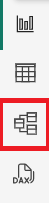

2. Use the model diagram to review the model design.

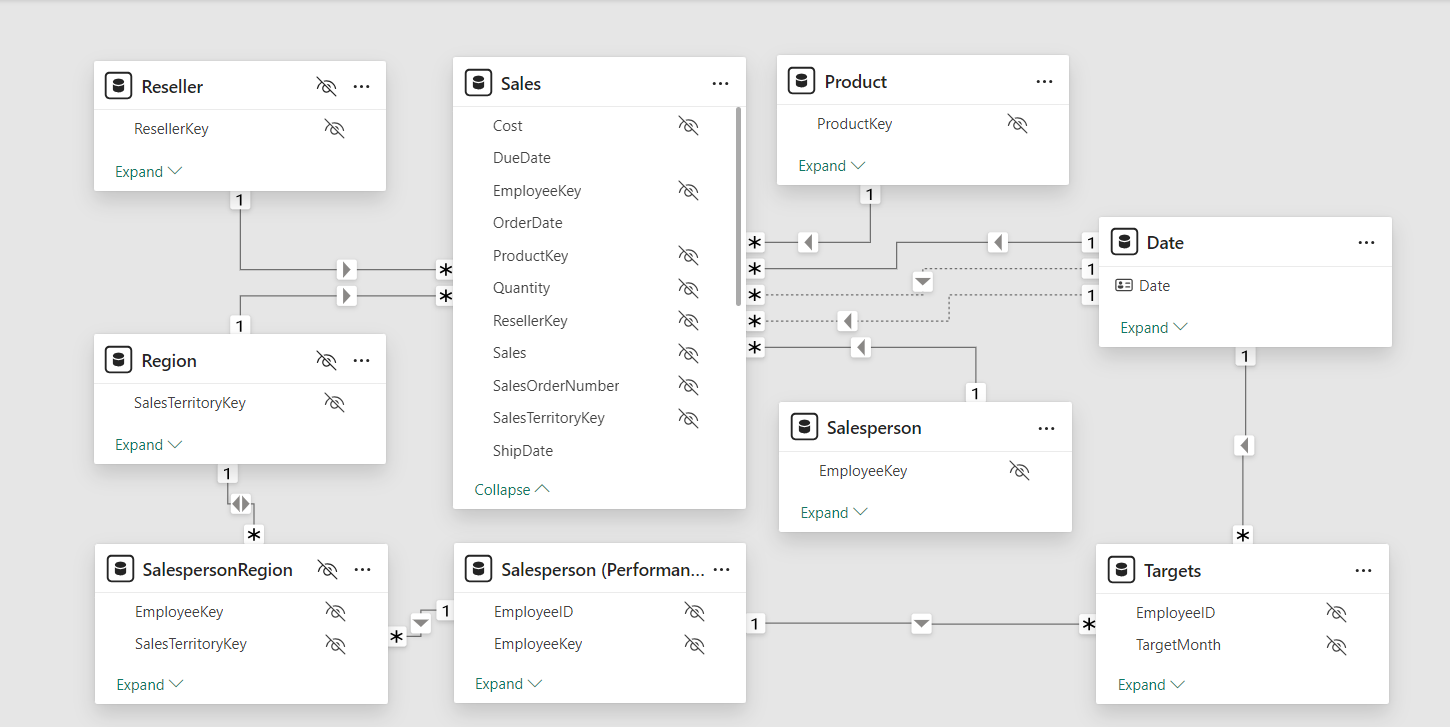

3. Notice that there are three relationships between the **Date** and **Sales** tables.

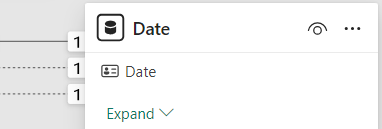

> The Date column in the Date table is a unique column representing the “one” side of the relationships. Filters applied to any column of the Date table propagate to the Sales table using one of the relationships.*

4. Hover the cursor over each of the three relationships to highlight the “many” side column in the **Sales** table.
5. Notice that the relationship between **Date** and **OrderDate** is active. The current model design indicates that the **Date** table is a role-playing dimension. This dimension could play the role of order date, due date, or ship date. Which role depends on the analytical requirements of the report.
> We’ll use DAX later to use these inactive relationships without creating another table just to get two active relationships for different date columns.

##### Visualize sales data by date
In this task, you will visualize the total sales by year and use inactive relationships.
1. Switch to Report view.

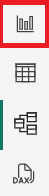

2. To add a table visual, in the **Visualizations** pane, select the **Table** visual icon.

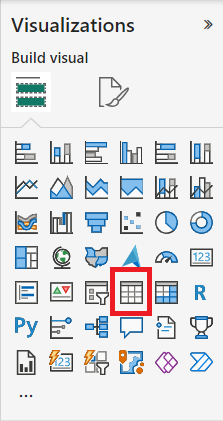

3. To add columns to the table visual, in the **Data** pane (located at the right), first expand the **Date** table.
4. Drag the **Year** column and drop it into the table visual.
5. Expand open the **Sales** table, and then drag and drop the **Total Sales** column into the table visual.
6. Review the table visual.

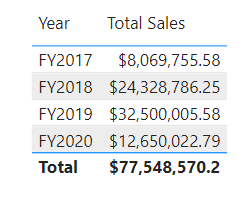

> The table visual shows the sum of the Total Sales column grouped by year. But what does Year mean? Because there’s an active relationship between the Date and Sales tables to the OrderDate column, Year means the fiscal year in which the orders were made.

##### Use inactive relationships
In this task, you will use the `USERELATIONSHIP` function to make an inactive relationship active.
1. In the **Data** pane, right-click the **Sales** table, and then select **New measure**.

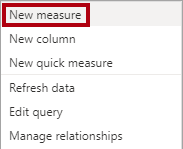

2. In the formula bar (located beneath the ribbon), replace the text with the following measure definition, and then press **Enter**.

```dax
Sales Shipped =
CALCULATE (
SUM ('Sales'[Sales]),
USERELATIONSHIP('Date'[Date], 'Sales'[ShipDate])
)
```
> This formula uses the `CALCULATE` function to modify the filter context. It’s the `USERELATIONSHIP` function that makes the `ShipDate` relationship active, only for this measure.

3. Add the **Sales Shipped** measure to the table visual.
4. Widen the table visual so all columns are fully visible. Observe that the **Total** row is the same but the sales amount for each year in **Total Sales** and **Sales Shipped** is different. That difference is due to orders being received in a given year while being shipped only in the following year or that are not even shipped yet.

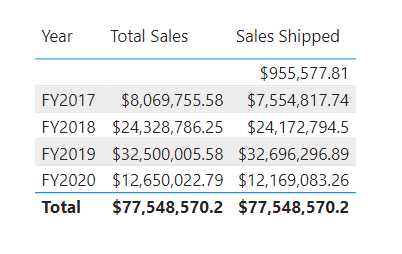

> Creating measures that temporarily set relationships as active is one way to work with role-playing dimensions. However, it can become tedious when there’s a need to create role-playing versions for many measures. For example, if there were 10 sales-related measures and three role-playing dates, it could mean creating 30 measures. Creating them with calculation groups makes the process easier.

#### Create calculation groups
In this task, you will create a calculation group for Time Intelligence analysis.
1. Switch to **Model** view.
2. In the Model view, select **Calculation Group** to create a new calculation group table, group column, and item. If a warning window pops up, select **Yes** to confirm the creation of the calculation group.

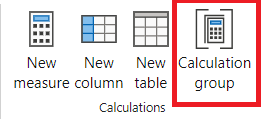

> Note: An implicit measure occurs when, in the Report view, you use a data column from the Data pane directly in a visual. The visual allows you to aggregate it as a `SUM`, `AVERAGE`, `MIN`, `MAX`, or some other basic aggregation, which becomes an implicit measure. Once you create a calculation group, Power BI Desktop won’t create implicit measures anymore, meaning you must create measures explicitly to aggregate data columns.

3. Rename the calculation group to *Time Calculations* and the calculation column to *Yearly Calculations*.
4. In the **Model** tab of the **Data** pane, select the calculation item automatically created with your calculation group.
5. Replace and commit the item’s formula with the following:

```dax
Year-to-Date (YTD) = CALCULATE(SELECTEDMEASURE(), DATESYTD('Date'[Date]))
```
6. Right-click on the **Calculation items** field and select **New calculation item**.
7. Use the following DAX formula for the new item:

```dax
Previous Year (PY) = CALCULATE(SELECTEDMEASURE(), PREVIOUSYEAR('Date'[Date]))
```
8. Create a third item with the following DAX formula:

```dax
Year-over-Year (YoY) Growth = 
VAR MeasurePriorYear =
CALCULATE(
    SELECTEDMEASURE(),
    SAMEPERIODLASTYEAR('Date'[Date])
)
RETURN
DIVIDE(
    (SELECTEDMEASURE() - MeasurePriorYear),
    MeasurePriorYear
)
```
The last calculation item should return values in percentage only, so it needs a dynamic format string to change the format of the measures it affects.
1. In the **Properties** pane of the YoY item, enable the **Dynamic format string** feature.
2. In the DAX formula bar, verify that the field to its left is set as **Format**, and write the following format string: `"0.##%"`
3. Confirm that your calculation group looks as follows:

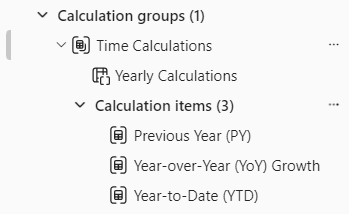

##### Apply a calculation group to measures
In this task, you will visualize how the calculation items affect measures in a visual.
1. Switch to **Report** view.
2. At the bottom of the canvas, select the **Overview** tab.
3. Select the matrix visual already created in the canvas and drag the **Yearly Calculations** calculation column from the **Data** pane to the **Columns** field in the **Visualizations** pane.

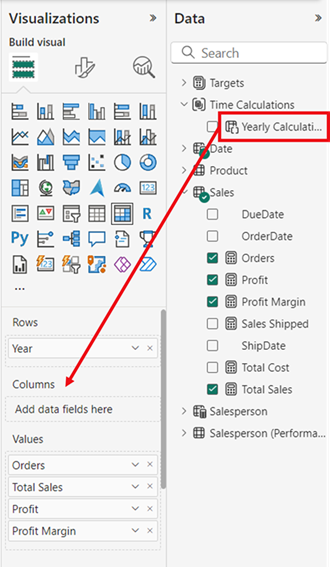

4. Observe that now the matrix has a set of sales figures for each calculation item.

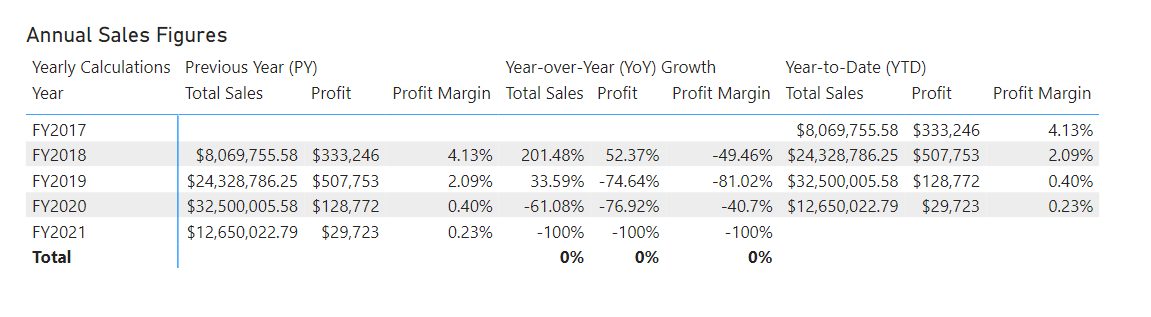

> Having all this information in one visual at once can be hard to read and therefore, it would be convenient to limit the visual to one sales figure at a time. In order to do that, we can use a field parameter.

#### Create field parameters
In this task, you will create field parameters to change visuals.
1. Select the **Modeling** tab in the top ribbon, then expand the **New parameter** button and select **Fields**.

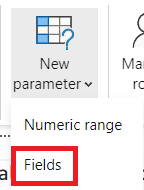

2. In the Parameters window, rename the parameter to **Sales Figures**, verify that the option Add slicer to this page is checked, and add the following fields from the Sales table:
    * Total Sales
    * Profit
    * Profit Margin
    * Orders

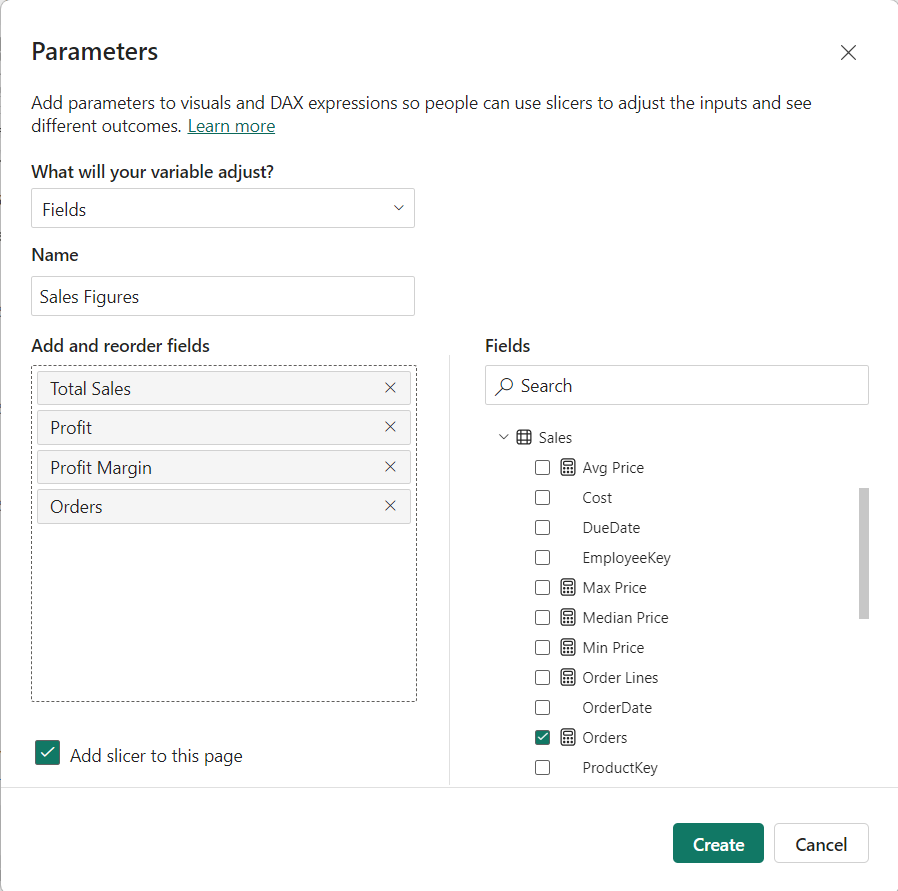

3. Select **Create**.
4. Once the slicer is created, you can select the matrix and remove all fields from **Values** in the Visualizations pane and add instead the Sales Figures field parameter.

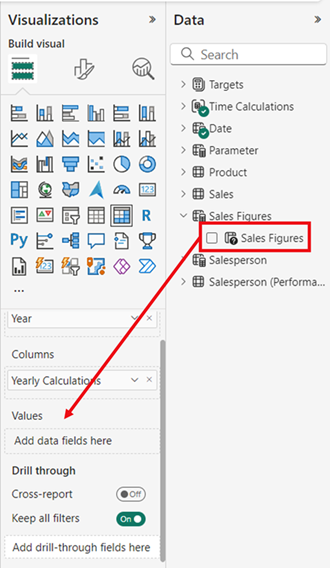

5. Check the different sales figures in the slicer and how the matrix changes when each of them is selected.
6. See how the Profit field is selected using the slicer for the Sales Figures field parameter. This is the same matrix from above, so you can see the three calculation items (PY, YoY, YTD) but only applied to Profit because of the slicer.

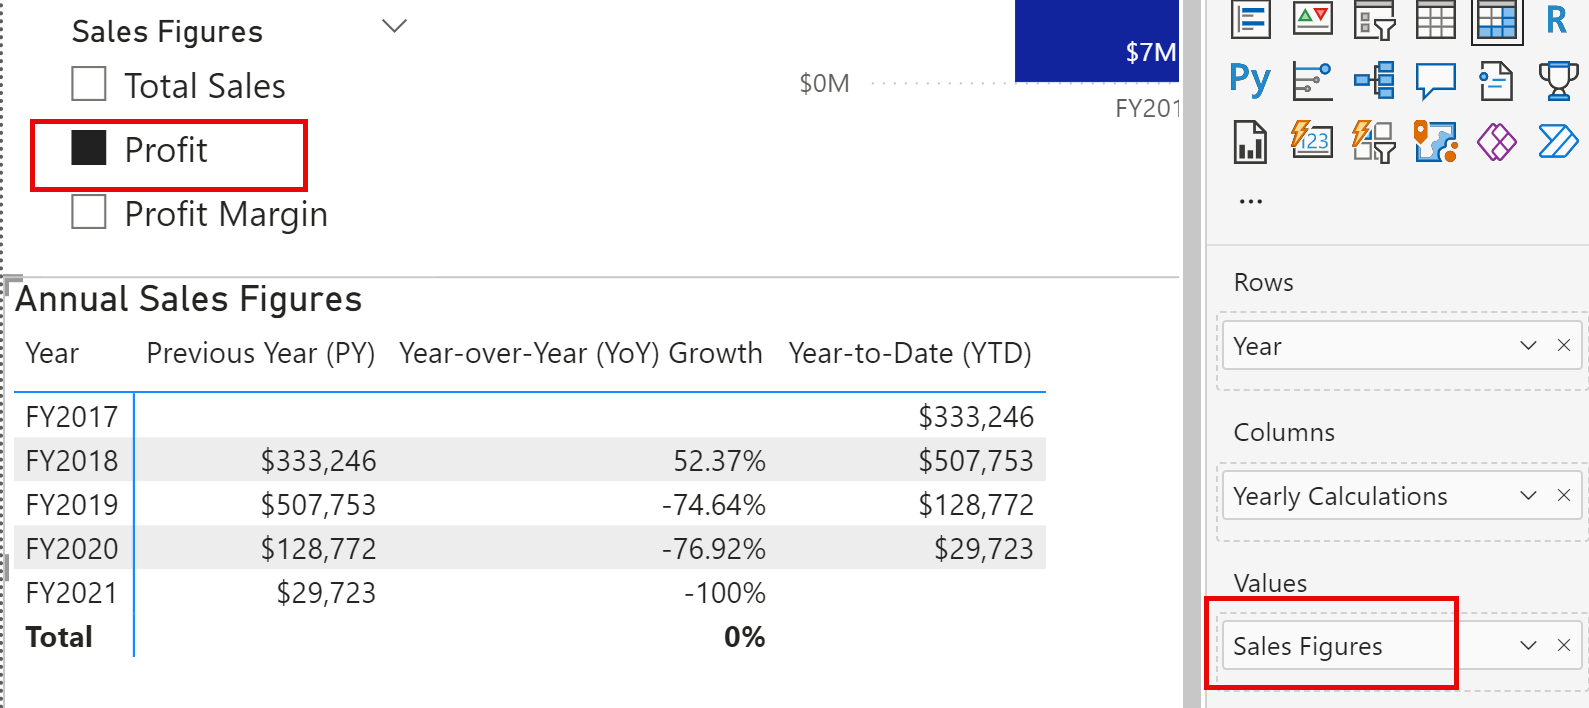

##### Edit field parameters
In this task, you will edit the **Sales Figures** field parameter by directly modifying its DAX expression.
1. Select the **Salesperson Performance** tab at the bottom of the canvas. Notice the clustered bar chart to switch the chart between Sales by Month and Target by Month.
> While creating the bookmark buttons allows you to change the visual type with each option, if you need to switch between many measures, you will have to create a bookmark button for each of them and that can be very time consuming. Instead, we can use a field parameter with all the measures we want to analyze and quickly switch between them.

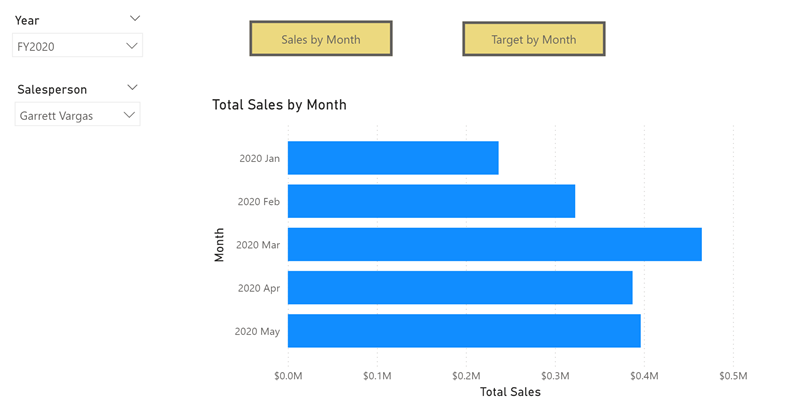

2. Select the bar chart visual and replace the **Total Sales** field in **X-axis** with the **Sales Figures** field parameter.
3. Create a **Slicer** visual and drag the **Sales Figures** parameter to the **Field** area.

For this visual you still need to evaluate the Target by Month, which is not in the field parameter.
1. Select the **Sales Figures** parameter in the Data pane and add the Target field in the parameter’s DAX expression as below:

```dax
Sales Figures = {
 ("Total Sales", NAMEOF('Sales'[Total Sales]), 0),
 ("Profit", NAMEOF('Sales'[Profit]), 1),
 ("Profit Margin", NAMEOF('Sales'[Profit Margin]), 2),
 ("Orders", NAMEOF('Sales'[Orders]), 3),
 ("Target", NAMEOF('Targets'[Target]), 4)
}
```
2. Commit the changes and verify that the visual changes as you select the different Sales figures.
3. Delete the bookmark buttons, and observe the final state of the report page.

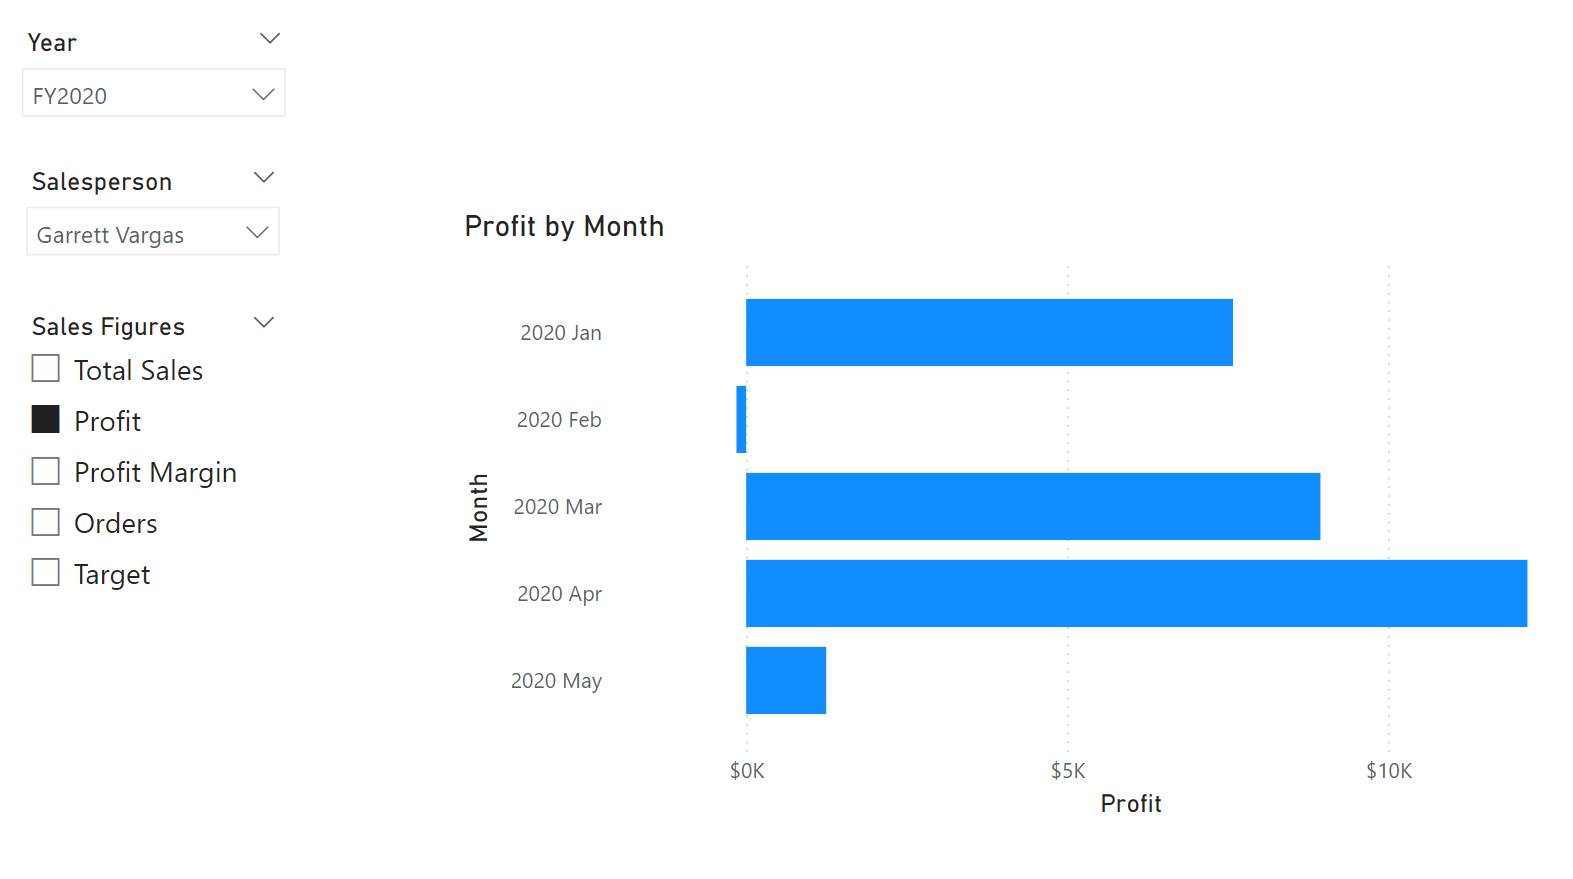

#### Lab complete
To finish the exercise, close Power BI Desktop - no need to save the file.

### **Module assessment**

#### 1. An analytics team builds a new semantic model in Microsoft Fabric with all data stored in a lakehouse. Which storage mode should they choose as the default for this model?

A) Import mode, because it provides the fastest query performance. \
**B) Direct Lake mode, because it reads Delta tables directly from OneLake without importing data.** \
C) DirectQuery mode, because it queries the source in real time.

#### 2. A company has 60 base measures in a semantic model and needs Year-to-Date, Quarter-to-Date, and Month-to-Date versions of each. What should a model designer implement to avoid creating 180 additional measures?

**A) A calculation group with time intelligence calculation items that use `SELECTEDMEASURE()`.** \
B) DAX variables to store intermediate results and reduce repeated calculations. \
C) Aggregations with pre-summarized tables at the monthly, quarterly, and yearly grain.

#### 3. A model designer needs to use Tabular Editor for external model development and deploy through CI/CD pipelines. Which setting is a prerequisite for XMLA endpoint read/write access?

**A) Large semantic model storage format.** \
B) OneLake integration. \
C) Query scaleout.

#### 4. A model designer enables the Assume referential integrity setting on a relationship between a fact table and a dimension table in a Direct Lake model. What is the performance benefit of this setting?

**A) The engine uses `INNER` joins instead of `LEFT OUTER` joins, which reduces the number of rows processed.** \
B) The engine caches relationship metadata so that subsequent queries skip relationship evaluation. \
C) The engine creates an index on the foreign key column to speed up relationship lookups.

#### 5. A semantic model has a fact table with 150 million rows. Report users primarily view monthly and quarterly summaries by region. Which design pattern improves query performance for these summary-level visuals?

**A) Aggregation tables that store precalculated totals at the monthly and quarterly grain.** \
B) Calculation groups with time intelligence calculation items. \
C) Bi-directional filtering between the fact and dimension tables.

## **Optimize semantic model performance**

### **Introduction**

#### Why Semantic Model Performance Matters
Semantic models power:

✅ Power BI Reports \
✅ Dashboards \
✅ Copilot \
✅ AI Experiences \
✅ Data Agents

When performance is good:
* Reports load quickly
* Users trust the data
* Copilot responds faster
* AI experiences work reliably

When performance is poor:

❌ Slow dashboards \
❌ Long report rendering times \
❌ Query timeouts \
❌ Poor user experience \
❌ AI response failures
#### Common Causes of Poor Performance
Performance problems can originate from:
##### DAX Calculations
Examples:
```
Complex `SUMX`
Nested `FILTER`
Expensive `LOOKUPVALUE`
```
##### Data Model Design
Examples:
* High-cardinality columns
* Too many calculated columns
* Poor relationships
##### Report Design
Examples:
* Too many visuals
* Too much data on one page
* Unoptimized filters
##### Large Fact Tables
Examples:
* Millions of rows
* Billions of transactions

without aggregations.
#### Performance Optimization Goals
The objective is not simply to know:
> The report is slow

but rather:
* What is slow?
* Why is it slow?
* How do we fix it?
#### Typical Troubleshooting Workflow
> Slow Report → Performance Analyzer → Identify Bottleneck → Optimize DAX → Optimize Model → Add Aggregations → Retest

#### Three Major Optimization Areas
This module focuses on:
##### 1. Diagnose Performance Problems
Using:
> Performance Analyzer

##### 2. Optimize DAX
Improve:
* Measures
* Calculations
* Iterator usage
##### 3. Optimize Data Model
Reduce:
* Cardinality
* Memory usage
* Query complexity
#### Performance Analyzer
##### Purpose
Performance Analyzer helps identify:

✅ Slow visuals \
✅ Query duration \
✅ Rendering time \
✅ DAX execution time
##### Questions it Answers
> Which visual is slow? \
> How long does each visual take? \
> Is the problem DAX or rendering?

#### DAX Optimization
Many performance problems originate from poorly designed calculations.
##### Prefer Aggregations
Use:
```dax
SUM()
```
instead of:
```dax
SUMX()
```
when possible.
##### Why?
Aggregation functions are faster because:
> Column-Based

rather than:
> Row-by-Row

processing.
##### Use Variables
Example:
```dax
VAR Revenue =
    SUM(Sales[Amount])

RETURN
Revenue
```
Benefits:

✅ Better readability \
✅ Reduced repeated calculations \
✅ Better maintainability
##### Avoid Expensive Functions
Examples:
```dax
LOOKUPVALUE()
SEARCH()
```
can be slow on large datasets.

Prefer:
```dax
RELATED()
```
when relationships exist.
#### Cardinality Optimization
##### What is Cardinality?
Number of unique values in a column.
##### Low Cardinality
**Region**
> East \
> West \
> North \
> South

4 unique values.

✅ Efficient
##### High Cardinality
> Customer Email

millions of unique values.

❌ Expensive
#### Why Cardinality Matters

High cardinality:

✅ Uses more memory

✅ Increases model size

✅ Slows queries

Reduce Cardinality

Examples:

Remove:

GUIDs
Transaction IDs
Unused Keys


if not needed for reporting.

Aggregations
What Are Aggregations?

Pre-calculated summary tables.

Example

Instead of reading:

500 Million Transactions


query:

Monthly Sales by Region


aggregation table.

Benefits

✅ Faster queries

✅ Less data scanning

✅ Better scalability

Example

Instead of:

Daily Sales Detail


for every query,

store:

Monthly Totals


for common reporting needs.

Enterprise Retail Example

Suppose:

Executive Dashboard


requires:

Monthly Revenue


not:

Individual Sales Transactions


Use aggregations.

AI and Performance

Copilot and AI rely on the same semantic model.

Slow models affect:

✅ Reports

✅ Dashboards

✅ AI Queries

✅ Copilot Responses

Faster Model = Better AI

Optimization improves:

User Experience
+
Copilot Experience


at the same time.

Most Common Optimization Targets
DAX

✅ Simplify calculations

✅ Use measures instead of calculated columns

✅ Use variables

Model

✅ Reduce cardinality

✅ Remove unused columns

✅ Use star schema

Query Performance

✅ Aggregations

✅ Efficient relationships

✅ Better storage mode choices

Performance Diagnosis Checklist
Step 1

Use:

Performance Analyzer

Step 2

Find:

Slow Visuals

Step 3

Review:

DAX Queries

Step 4

Evaluate:

Data Model Design

Step 5

Implement:

Aggregations


if necessary.

Exam Quick Facts

✅ Semantic model performance impacts:

Reports
Dashboards
Copilot
AI experiences

✅ Performance Analyzer is the primary diagnostic tool

✅ Common bottlenecks:

DAX calculations
High cardinality
Large datasets
Poor model design

✅ Aggregation functions are generally faster than iterator functions

✅ High-cardinality columns increase:

Memory usage
Query duration
Model size

✅ Aggregations improve performance for large fact tables

✅ Performance optimization should focus on:

DAX
Cardinality
Aggregations
Memory Trick

Diagnose → Optimize → Aggregate

or

Performance = DAX + Model + Aggregations

⭐ Most exam-focused takeaway:

Use Performance Analyzer first to identify the bottleneck before attempting optimization.